In [14]:
# 数据预处理通用导入
import os
import re
import time
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import requests
import fits
from concurrent.futures import ThreadPoolExecutor, as_completed

In [15]:
# 天文数据与预处理相关导入
import warnings
import scipy
from scipy import signal
from scipy.interpolate import splev, splrep

import astropy.io.fits as afits
from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.labelsize': 'x-large'})

# Data processing

In [16]:
# full preprocessing pipeline: integrate file loading + labeling + loading + uid dedup + anomaly filter
import importlib
import spectra_io as _sio
importlib.reload(_sio)

# Choose available pipeline entrypoint
if hasattr(_sio, 'run_screening_preprocess_from_files'):
    run_pipeline_from_files = _sio.run_screening_preprocess_from_files
    _use_file_wrapper = True
elif hasattr(_sio, 'run_screening_preprocess_pipeline'):
    run_screening_preprocess_pipeline = _sio.run_screening_preprocess_pipeline
    _use_file_wrapper = False
else:
    raise ImportError(
        'spectra_io 中未找到可用的预处理管线函数。'
    )

# export function
if hasattr(_sio, 'export_spectra_csv'):
    export_spectra_csv = _sio.export_spectra_csv
elif hasattr(_sio, 'export_datacube_csv'):
    export_spectra_csv = _sio.export_datacube_csv
else:
    raise ImportError(
        'spectra_io 中未找到 export_spectra_csv。'
    )

common_wave = np.arange(3800.0, 4500.0, 1.0)

if _use_file_wrapper:
    # New integrated path: no external stars_df required
    pipe = run_pipeline_from_files(
        stars_csv='stars.csv',
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )
else:
    # Backward compatible fallback
    if 'stars_df' not in globals():
        stars_df = pd.read_csv('stars.csv')
    pipe = run_screening_preprocess_pipeline(
        stars_df=stars_df,
        common_wave=common_wave,
        folder='dr13_new',
        cn_catalogs=['CNstar.csv', 'FT_cands.csv'],
        cn_match_tolerance_arcsec=1.0,
        uid_col='uid',
        snr_col='snru',
        anomaly_low_pct=0.5,
        anomaly_high_pct=99.5,
        show_progress=True,
    )

X_clean = pipe['datacube_clean']
stars_clean = pipe['stars_clean']
stars_df = pipe.get('stars_stage_dropna_labeled', stars_clean.copy())

print('summary:', pipe['summary'])
print('label_report:', pipe['label_report'])
print('dedup_report:', pipe['dedup_report'])
print('anomaly_report:', pipe['anomaly_report'])
print('X_clean shape:', X_clean.shape, 'stars_clean shape:', stars_clean.shape)

# Optional export for cross-notebook use (disabled by default)
# meta_cols = [c for c in ['ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'uid', 'filepath', 'label'] if c in stars_clean.columns]
# out_csv = 'spectra_clean_wide.csv'
# export_spectra_csv(
#     datacube=X_clean,
#     common_wave=common_wave,
#     out_csv=out_csv,
#     metadata_df=stars_clean[meta_cols],
#     flux_prefix='flux_',
#     wave_digits=1,
# )
# print('exported:', out_csv)

# if len(pipe.get('load_drop_log', [])) > 0:
#     display(pipe['load_drop_log'].head())

  0%|          | 0/48440 [00:00<?, ?it/s]

summary: {'n_input': 48440, 'n_after_dropna': 48440, 'n_positive_labeled': 107, 'n_loaded': 37182, 'n_normalized_ok': 37182, 'n_after_uid_dedup': 34204, 'n_after_anomaly_filter': 33589}
label_report: {'n_catalog_rows': 148, 'n_match_unique': 107, 'n_positive': 107, 'n_unlabeled': 48333, 'tolerance_arcsec': 1.0}
dedup_report: {'n_before': 37182, 'n_after': 34204, 'n_removed': 2978, 'uid_col': 'uid', 'snr_col': 'snru'}
anomaly_report: {'n_before': 34204, 'n_after': 33589, 'n_removed': 615, 'median_low': 1.0172393333911895, 'median_high': 1.0697653943300247, 'mad_low': 0.038511829376220705, 'mad_high': 0.11002329126000406}
X_clean shape: (33589, 700) stars_clean shape: (33589, 17)


# KNN 聚类

In [17]:
# KNN + 分子带掩盖聚类约束（先掩盖分子带，再聚类，再做邻域）
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

knn_param_cols = ['teff', 'logg', 'feh']
knn_param_cols = [c for c in knn_param_cols if c in stars_clean.columns]
if len(knn_param_cols) < 3:
    raise RuntimeError(f'可用于KNN中心向量的列不足，当前仅有: {knn_param_cols}')

param_df = stars_clean[knn_param_cols].apply(pd.to_numeric, errors='coerce')
param_df = param_df.fillna(param_df.median(numeric_only=True))

scaler = StandardScaler()
X_params_scaled = scaler.fit_transform(param_df.values)

if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，请先执行光谱预处理单元。')
if len(X_clean) != len(stars_clean):
    raise RuntimeError('X_clean 与 stars_clean 行数不一致，无法构建掩盖聚类。')

# Step 1: 先对 CN/CH 分子带做掩盖，避免分子带直接主导聚类
masked_cube = np.asarray(X_clean, dtype=float).copy()
for l1, l2 in [(3830, 3883), (4120, 4216), (4285, 4315)]:
    m = (common_wave >= l1) & (common_wave <= l2)
    fill_vals = np.nanmedian(masked_cube[:, ~m], axis=1)
    fill_vals = np.where(np.isfinite(fill_vals), fill_vals, 1.0)
    masked_cube[:, m] = fill_vals[:, None]

# Step 2: 在掩盖后的光谱上降维 + 聚类
n_samples = masked_cube.shape[0]
n_components_masked = int(min(25, masked_cube.shape[1], max(2, n_samples - 1)))
X_masked_emb = PCA(n_components=n_components_masked, random_state=42).fit_transform(masked_cube)

n_clusters_masked = int(np.clip(np.sqrt(n_samples) / 2, 10, 45))
kmeans_masked = KMeans(n_clusters=n_clusters_masked, random_state=42, n_init=20)
masked_labels = kmeans_masked.fit_predict(X_masked_emb)
stars_clean['masked_cluster_id'] = masked_labels

# Step 3: 在每个掩盖簇内优先做参数空间 KNN，不足时用全局补齐
K = 180
global_knn = NearestNeighbors(n_neighbors=min(K + 1, len(stars_clean)), metric='euclidean', algorithm='auto')
global_knn.fit(X_params_scaled)
global_distances, global_indices = global_knn.kneighbors(X_params_scaled)

neighbor_indices_all = []
neighbor_distances_all = []
for i in range(len(stars_clean)):
    cid = masked_labels[i]
    local_idx = np.where(masked_labels == cid)[0]

    if len(local_idx) >= 3:
        local_X = X_params_scaled[local_idx]
        local_k = min(K + 1, len(local_idx))
        local_knn = NearestNeighbors(n_neighbors=local_k, metric='euclidean', algorithm='auto')
        local_knn.fit(local_X)
        local_pos = int(np.where(local_idx == i)[0][0])
        d_loc, idx_loc = local_knn.kneighbors(local_X[local_pos].reshape(1, -1))
        nb_local = local_idx[idx_loc[0]]
        dd_local = d_loc[0]
        keep = nb_local != i
        nb = nb_local[keep].tolist()
        dd = dd_local[keep].tolist()
    else:
        nb, dd = [], []

    if len(nb) < K:
        g_nb = global_indices[i, 1:].tolist()
        g_dd = global_distances[i, 1:].tolist()
        for j, d in zip(g_nb, g_dd):
            if j not in nb:
                nb.append(int(j))
                dd.append(float(d))
            if len(nb) >= K:
                break

    neighbor_indices_all.append(np.asarray(nb[:K], dtype=int))
    neighbor_distances_all.append(np.asarray(dd[:K], dtype=float))

stars_clean['neighbor_indices'] = neighbor_indices_all
stars_clean['neighbor_distances'] = neighbor_distances_all

# Step 4: 计算 KNN 中心与距离概率特征
center_scaled = np.zeros_like(X_params_scaled, dtype=float)
center_euclid = np.full(len(stars_clean), np.nan, dtype=float)
for i, nb in enumerate(stars_clean['neighbor_indices']):
    nb = np.asarray(nb, dtype=int)
    if nb.size == 0:
        continue
    local_center = X_params_scaled[nb].mean(axis=0)
    center_scaled[i] = local_center
    center_euclid[i] = np.linalg.norm(X_params_scaled[i] - local_center)

center_orig = scaler.inverse_transform(center_scaled)
for j, col in enumerate(knn_param_cols):
    stars_clean[f'knn_center_{col}'] = center_orig[:, j]

stars_clean['knn_center_euclid'] = center_euclid


print(f'KNN features: {knn_param_cols}, K={K}, masked_clusters={n_clusters_masked}')

KNN features: ['teff', 'logg', 'feh'], K=180, masked_clusters=45


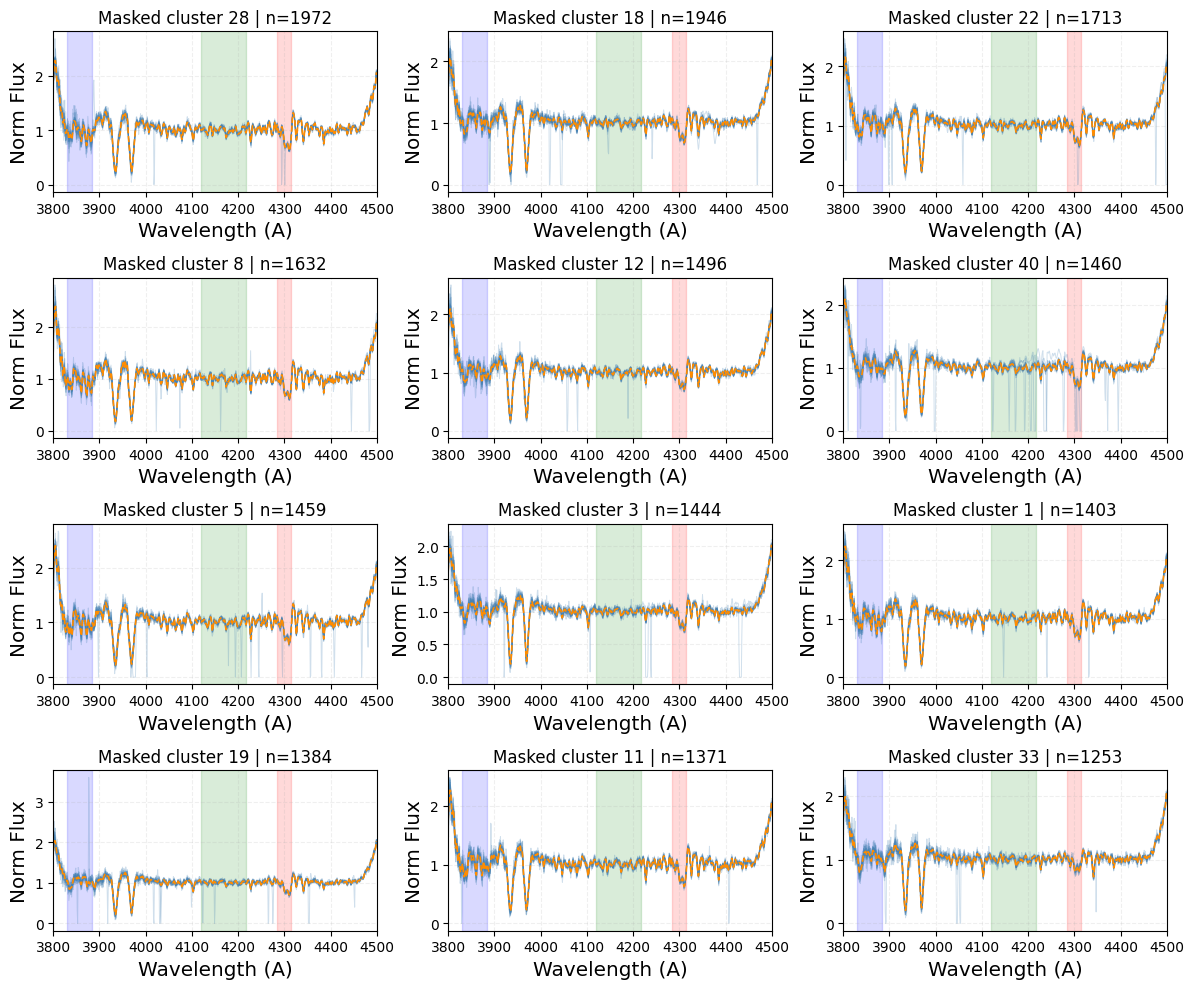

In [26]:
# 分子带掩盖聚类可视化
if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id，请先运行 KNN + 掩盖聚类单元。')
if 'X_clean' not in globals() or len(X_clean) != len(stars_clean):
    raise RuntimeError('缺少 X_clean 或行数不一致，无法可视化聚类光谱。')

n_groups = 12
n_spectra_per_group = 20
np.random.seed(42)

cluster_counts = stars_clean['masked_cluster_id'].value_counts().sort_values(ascending=False)
selected_clusters = cluster_counts.head(min(n_groups, len(cluster_counts))).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(12, 10))
axes = axes.flatten()

for ax_idx, cid in enumerate(selected_clusters):
    ax = axes[ax_idx]
    idxs = np.where(stars_clean['masked_cluster_id'].values == cid)[0]

    if len(idxs) > n_spectra_per_group:
        idxs_plot = np.random.choice(idxs, size=n_spectra_per_group, replace=False)
    else:
        idxs_plot = idxs

    ax.axvspan(3830, 3883, alpha=0.15, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.15, color='green', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.15, color='red', zorder=0)

    for idx in idxs_plot:
        ax.plot(common_wave, X_clean[idx], color='steelblue', alpha=0.25, linewidth=0.7, zorder=1)

    mean_flux = np.nanmean(X_clean[idxs], axis=0)
    ax.plot(common_wave, mean_flux, color='darkorange', linewidth=1.2, linestyle='--', zorder=2)

    ax.set_title(f'Masked cluster {cid} | n={len(idxs)}')
    ax.set_xlim(3800, 4500)
    ax.set_xlabel('Wavelength (A)')
    ax.set_ylabel('Norm Flux')
    ax.grid(alpha=0.2, linestyle='--')

for j in range(len(selected_clusters), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


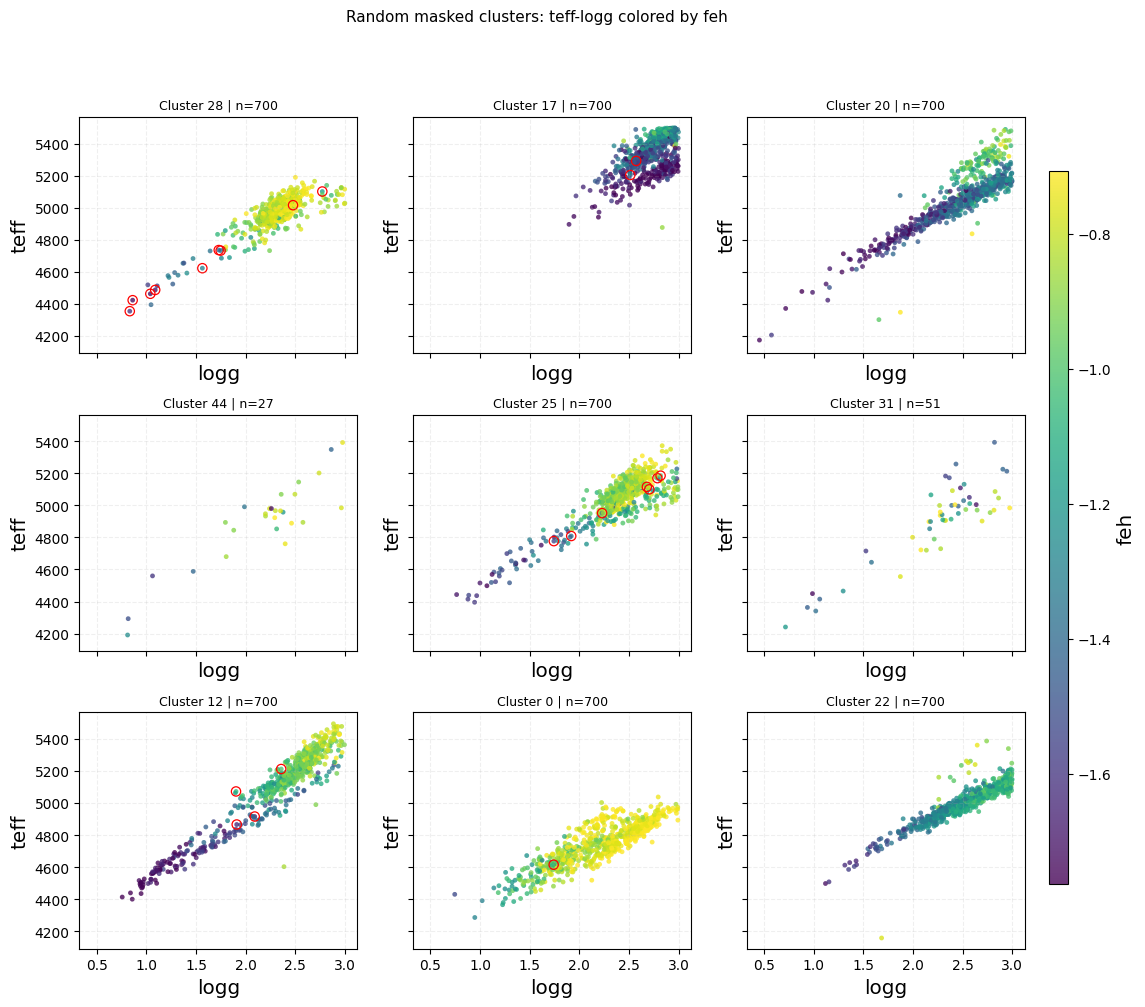

In [34]:
# KNN参数聚类可视化（稳定显示版）：teff-logg 平面 + feh colorbar
# 说明：该单元临时使用 inline 后端，避免 widget 后端在多子图下卡顿

if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id，请先运行 KNN + 掩盖聚类单元。')

need_cols = ['teff', 'logg', 'feh', 'label', 'masked_cluster_id']
missing = [c for c in need_cols if c not in stars_clean.columns]
if missing:
    raise RuntimeError(f'缺少必要列: {missing}')

vis_df = stars_clean[need_cols].copy()
for c in need_cols:
    vis_df[c] = pd.to_numeric(vis_df[c], errors='coerce')
vis_df = vis_df.dropna(subset=['teff', 'logg', 'feh', 'masked_cluster_id']).reset_index(drop=True)

if len(vis_df) == 0:
    raise RuntimeError('无有效样本可视化。')

seed = 5

n_show_clusters = 9
min_points_per_cluster = 10
max_points_each_cluster = 700
invert_teff_axis = True

cluster_counts = vis_df['masked_cluster_id'].value_counts().sort_index()
eligible_clusters = cluster_counts[cluster_counts >= min_points_per_cluster].index.to_numpy()
if eligible_clusters.size == 0:
    raise RuntimeError('没有满足最小点数要求的簇，请调小 min_points_per_cluster。')

rng = np.random.default_rng(seed)
pick_n = int(min(n_show_clusters, eligible_clusters.size))
selected_clusters = rng.choice(eligible_clusters, size=pick_n, replace=False)

ncols = 3
nrows = int(np.ceil(pick_n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.2, 3.6 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

vmin = float(np.nanpercentile(vis_df['feh'].values, 2))
vmax = float(np.nanpercentile(vis_df['feh'].values, 98))
if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin >= vmax):
    vmin = float(np.nanmin(vis_df['feh'].values))
    vmax = float(np.nanmax(vis_df['feh'].values))

sc = None
for k, cid in enumerate(selected_clusters):
    ax = axes[k]
    sub = vis_df[vis_df['masked_cluster_id'] == cid]

    if len(sub) > max_points_each_cluster:
        sub = sub.sample(max_points_each_cluster, random_state=seed)

    sc = ax.scatter(
        sub['logg'],
        sub['teff'],
        c=sub['feh'],
        cmap='viridis',
        s=12,
        alpha=0.78,
        vmin=vmin,
        vmax=vmax,
        edgecolors='none',
    )

    # 用红色空心圈标注已知CN，避免重复图例导致渲染慢
    known = sub['label'] == 1
    if known.any():
        ax.scatter(
            sub.loc[known, 'logg'],
            sub.loc[known, 'teff'],
            s=45,
            facecolors='none',
            edgecolors='red',
            linewidths=0.9,
        )

    ax.set_title(f'Cluster {int(cid)} | n={len(sub)}', fontsize=9)
    ax.set_ylabel('teff')
    ax.set_xlabel('logg')
    ax.grid(alpha=0.20, linestyle='--')


for j in range(pick_n, len(axes)):
    axes[j].axis('off')

fig.subplots_adjust(right=0.90, top=0.88, wspace=0.20, hspace=0.26)
if sc is not None:
    cax = fig.add_axes([0.92, 0.17, 0.015, 0.66])
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label('feh')

fig.suptitle('Random masked clusters: teff-logg colored by feh', fontsize=11)
plt.show()


## 基于簇均值谱面积积分的 CN 吸收筛选

In [21]:
# 面积积分法
from scipy import signal

if 'masked_cluster_id' not in stars_clean.columns:
    raise RuntimeError('缺少 masked_cluster_id，请先运行 KNN 掩盖聚类单元。')
if 'X_clean' not in globals() or len(X_clean) != len(stars_clean):
    raise RuntimeError('缺少 X_clean 或行数不一致，无法进行面积积分筛选。')

band_cn = {
    'CN3839': (3830, 3883),
    'CN4142': (4120, 4216),
    'CH4300': (4285, 4315),
}

def _safe_smooth(y, win=9, poly=2):
    y = np.asarray(y, dtype=float)
    w = int(win)
    if w % 2 == 0:
        w += 1
    if y.size < max(w, poly + 3):
        return y
    return signal.savgol_filter(y, window_length=w, polyorder=poly, mode='interp')

def _trapz_signed(y, x):
    return float(np.trapz(y, x))

def robust_zscore(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    mad = np.nanmedian(np.abs(arr - med)) + 1e-8
    return (arr - med) / mad

def robust_upper(x, q=0.995, k=5.0):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-8
    return float(min(med + k * mad, np.nanquantile(x, q)))

# 1) 构建簇参考中位谱
cluster_median_flux = {}
cluster_ids = stars_clean['masked_cluster_id'].values
for cid in np.unique(cluster_ids):
    idxs = np.where(cluster_ids == cid)[0]
    cluster_median_flux[int(cid)] = np.nanmedian(X_clean[idxs], axis=0)

# 2) 计算面积特征
rows = []
for i in range(len(stars_clean)):
    cid = int(cluster_ids[i])
    flux = np.asarray(X_clean[i], dtype=float)
    ref = np.asarray(cluster_median_flux[cid], dtype=float)
    diff_raw = ref - flux
    diff_smooth = _safe_smooth(diff_raw, win=9, poly=2)

    rec = {'spec_idx': i}
    for name, (l1, l2) in band_cn.items():
        m = (common_wave >= l1) & (common_wave <= l2)
        x = common_wave[m]
        d_raw = diff_raw[m]
        d_sm = diff_smooth[m]
        width = max(float(l2 - l1), 1.0)
        rec[f'{name}_signed_area'] = _trapz_signed(d_sm, x) / width
        rec[f'{name}_abs_frac'] = float(np.mean(d_sm > 0)) if d_sm.size > 0 else np.nan
        rec[f'{name}_peak_depth'] = float(np.nanmax(d_raw)) if d_raw.size > 0 else np.nan
    rows.append(rec)

area_df = pd.DataFrame(rows)
area_screen_df = pd.concat([stars_clean.reset_index(drop=True), area_df], axis=1)

for c in ['CN3839_signed_area', 'CN4142_signed_area']:
    area_screen_df[c] = area_screen_df[c] - float(np.nanmedian(area_screen_df[c].values))

area_screen_df['z_CN3839_area'] = robust_zscore(area_screen_df['CN3839_signed_area'].values)
area_screen_df['z_CN4142_area'] = robust_zscore(area_screen_df['CN4142_signed_area'].values)
area_screen_df['cn_shape_score'] = np.minimum(area_screen_df['z_CN3839_area'], area_screen_df['z_CN4142_area'])
area_screen_df['cn_area_score'] = (
    0.85 * area_screen_df['z_CN3839_area']
    + 0.85 * area_screen_df['z_CN4142_area']
    + 0.75 * area_screen_df['cn_shape_score']
)

known_mask = area_screen_df['label'] == 1
unl_mask = area_screen_df['label'] == -1
n_known = int(known_mask.sum())
n_unl = int(unl_mask.sum())

ch_center = float(np.nanmedian(area_screen_df.loc[known_mask, 'CH4300_signed_area'].values)) if n_known > 0 else float(np.nanmedian(area_screen_df['CH4300_signed_area'].values))
area_screen_df['CH4300_dev_abs'] = np.abs(area_screen_df['CH4300_signed_area'].values - ch_center)

# 3) 保留当前有效召回的基础约束
kn_cn3839 = area_screen_df.loc[known_mask, 'CN3839_signed_area'].values if n_known > 0 else area_screen_df['CN3839_signed_area'].values
kn_cn4142 = area_screen_df.loc[known_mask, 'CN4142_signed_area'].values if n_known > 0 else area_screen_df['CN4142_signed_area'].values
th_cn3839 = float(np.nanquantile(kn_cn3839, 0.03))
th_cn4142 = float(np.nanquantile(kn_cn4142, 0.03))
ub_cn3839 = robust_upper(kn_cn3839, q=0.999, k=5.5)
ub_cn4142 = robust_upper(kn_cn4142, q=0.999, k=5.5)
th_frac3839 = max(float(np.nanquantile(area_screen_df.loc[known_mask, 'CN3839_abs_frac'].values if n_known > 0 else area_screen_df['CN3839_abs_frac'].values, 0.02)), 0.10)
th_frac4142 = max(float(np.nanquantile(area_screen_df.loc[known_mask, 'CN4142_abs_frac'].values if n_known > 0 else area_screen_df['CN4142_abs_frac'].values, 0.02)), 0.10)
th_peak_4142 = float(np.nanquantile(area_screen_df.loc[known_mask, 'CN4142_peak_depth'].values if n_known > 0 else area_screen_df['CN4142_peak_depth'].values, 0.9995))

known_cn_band = area_screen_df.loc[known_mask, ['CN3839_signed_area', 'CN4142_signed_area']].values if n_known > 0 else area_screen_df[['CN3839_signed_area', 'CN4142_signed_area']].values
med_k_cn = np.nanmedian(known_cn_band, axis=0)
mad_k_cn = np.nanmedian(np.abs(known_cn_band - med_k_cn), axis=0) + 1e-8
all_cn_band = area_screen_df[['CN3839_signed_area', 'CN4142_signed_area']].values
known_like_dist = np.sqrt(np.nansum(((all_cn_band - med_k_cn) / mad_k_cn) ** 2, axis=1))
area_screen_df['known_like_dist'] = known_like_dist
th_known_like = float(np.nanquantile(known_like_dist[known_mask.values], 0.999) + 2.0) if n_known > 0 else float(np.nanquantile(known_like_dist, 0.999))

base_mask = (
    (area_screen_df['CN3839_signed_area'] >= th_cn3839)
    & (area_screen_df['CN4142_signed_area'] >= th_cn4142)
    & (area_screen_df['CN3839_signed_area'] <= ub_cn3839)
    & (area_screen_df['CN4142_signed_area'] <= ub_cn4142)
    & (area_screen_df['CN3839_abs_frac'] >= th_frac3839)
    & (area_screen_df['CN4142_abs_frac'] >= th_frac4142)
    & (area_screen_df['CN4142_peak_depth'] <= th_peak_4142)
    & (area_screen_df['known_like_dist'] <= th_known_like)
)

# 4) 固定参数（联合微调后）
th_shape = -0.55
th_score = 1.10
ch_dev_limit = 0.045
selected_use_ch = True

area_rule_mask = base_mask & (
    (area_screen_df['cn_shape_score'] >= th_shape)
    & (area_screen_df['cn_area_score'] >= th_score)
    & (area_screen_df['CH4300_dev_abs'] <= ch_dev_limit)
)

area_candidate_mask = area_rule_mask & (area_screen_df['label'] == -1)
area_known_hit_mask = area_rule_mask & (area_screen_df['label'] == 1)

area_screen_df['cn_area_rule_hit'] = area_rule_mask.astype(int)
area_screen_df['cn_area_known_hit'] = area_known_hit_mask.astype(int)
area_screen_df['cn_area_candidate'] = area_candidate_mask.astype(int)

cn_area_candidates = area_screen_df.loc[area_candidate_mask].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)
n_total = len(area_screen_df)
n_known_hit = int(area_known_hit_mask.sum())
area_known_recall = float(n_known_hit / max(n_known, 1))

# 5) 按需输出
print(f'总数: {n_total}')
print(f'候选数: {len(cn_area_candidates)}')
print(f'召回数: {n_known_hit}')
print(f'召回率: {area_known_recall:.3f}')

top_cols = [
    c for c in [
        'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'filepath',
        'CN3839_signed_area', 'CN4142_signed_area', 'CH4300_signed_area',
        'cn_shape_score', 'cn_area_score', 'CH4300_dev_abs'
    ] if c in cn_area_candidates.columns
]
print('\nTop10候选参数:')
display(cn_area_candidates[top_cols].head(10))


总数: 33589
候选数: 8224
召回数: 61
召回率: 0.836

Top10候选参数:


,uid,ra,dec,teff,logg,feh,rv,snru,filepath,CN3839_signed_area,CN4142_signed_area,CH4300_signed_area,cn_shape_score,cn_area_score,CH4300_dev_abs
0,G15626569425898,157.985949,7.647300,5091.62,2.187,-1.073,-30.24,5.89,dr13_new\spec-60759-LN103605N070210VB01_sp03-2...,0.130805,0.019847,-0.037405,12.134740,32.282267,0.017620
1,G16530491689721,72.190746,2.727773,4505.94,1.893,-0.769,58.26,7.96,dr13_new\spec-56660-VB073N02V1_sp03-056.fits.gz,0.093776,0.024620,-0.013208,10.852128,30.158528,0.006577
2,G16665632766330,59.715710,18.773125,4851.71,2.068,-1.419,64.05,9.39,dr13_new\spec-58879-KII035606N204618V01_sp01-1...,0.100370,0.020691,-0.007420,11.615268,29.337592,0.012365
3,G14438880384581,233.551930,0.326274,4821.92,1.767,-1.586,-53.00,6.85,dr13_new\spec-57866-HD153504N014009V01_sp05-01...,0.107689,0.019036,0.007332,11.638821,29.215012,0.027117
4,G11164235221213,208.520702,-2.711515,4517.39,1.354,-0.926,176.29,11.16,dr13_new\spec-56738-HD134838S025025V_sp09-244....,0.085271,0.024389,-0.032724,9.867888,28.463768,0.012939
5,G15400802633759,178.182230,6.815916,4921.79,2.739,-0.804,-28.50,18.29,dr13_new\spec-60434-LN115745N065828BM01_sp03-1...,0.098967,0.019074,0.010860,11.452878,28.237601,0.030645
6,G16069016242011,123.322086,5.354639,4571.71,1.804,-0.704,0.97,10.34,dr13_new\spec-57026-HD080932N055536V01_sp08-13...,0.141328,0.014485,0.022245,8.856350,28.072000,0.042030
7,G11033722056272,199.042368,-2.057600,4949.71,2.292,-1.353,35.89,5.60,dr13_new\spec-57887-HD131404S024825V02_sp09-17...,0.097393,0.019249,-0.007335,11.270716,28.036947,0.012450
8,G17374572562214,20.258302,45.515381,4723.44,1.877,-0.701,-91.58,11.69,dr13_new\spec-57378-HD012155N471656V01_sp01-07...,0.095793,0.018361,0.023319,11.085634,27.279643,0.043104
9,G17328400926264,16.741112,46.640850,4845.01,2.006,-1.477,-279.82,9.51,dr13_new\spec-58016-HD005843N470211B01_sp08-07...,0.092255,0.019216,-0.001864,10.676187,27.068463,0.017921


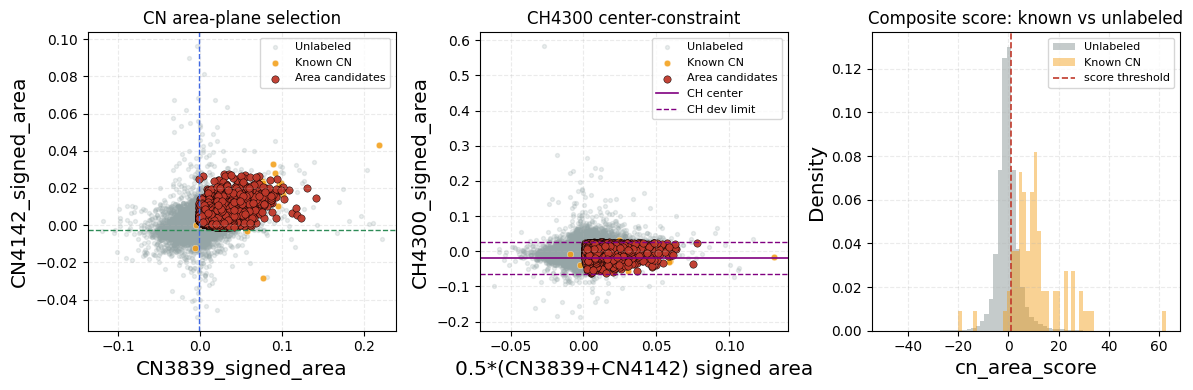

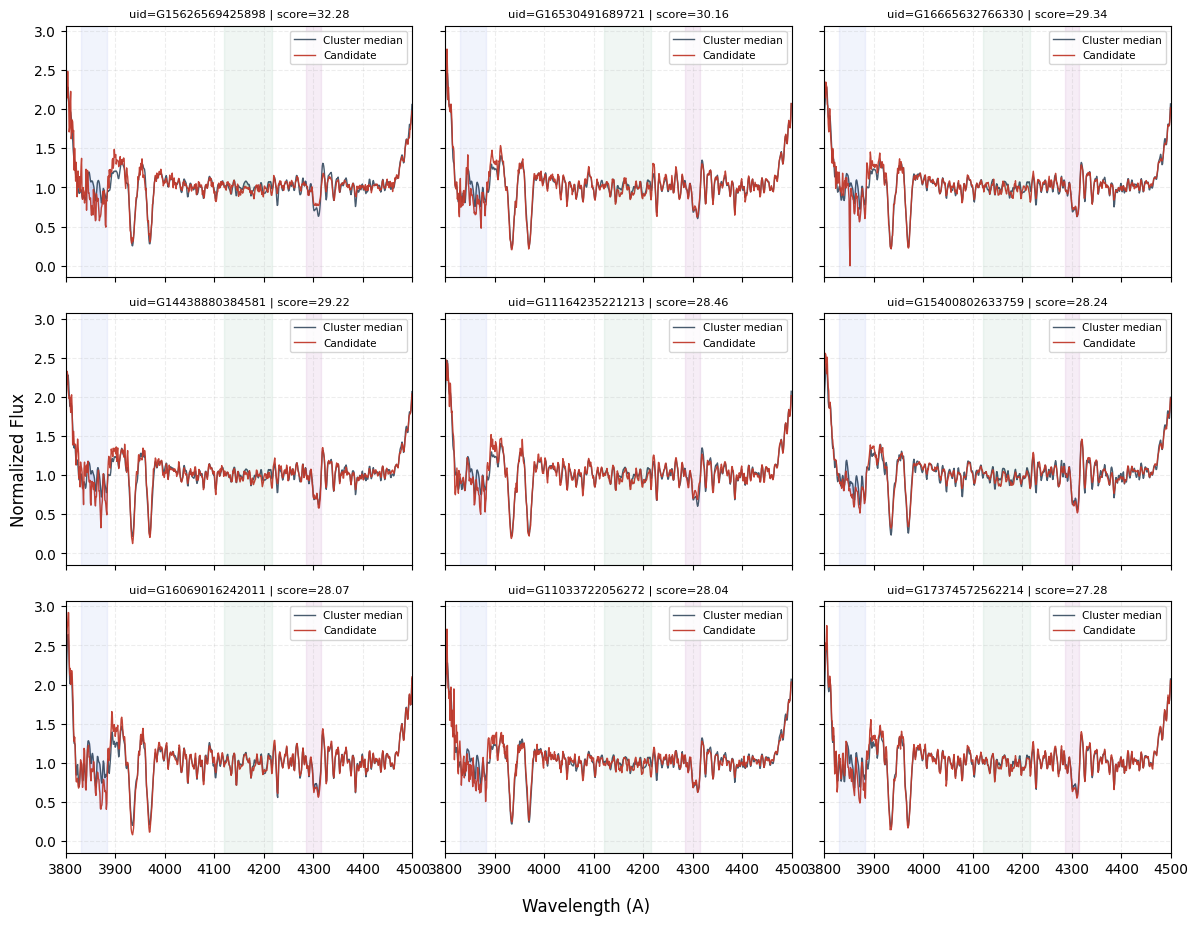

In [ ]:
# 面积积分法结果可视化：CH放松 + CN主导后分布
if 'cn_area_candidates' not in globals() or len(cn_area_candidates) == 0:
    print('面积积分法当前无候选，请先运行上一单元。')
else:
    vis = area_screen_df.copy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    m_unl = vis['label'] == -1 
    m_kn = vis['label'] == 1
    m_cand = vis['cn_area_candidate'] == 1

    # 图1：CN3839 vs CN4142
    axes[0].scatter(
        vis.loc[m_unl, 'CN3839_signed_area'], vis.loc[m_unl, 'CN4142_signed_area'],
        s=8, alpha=0.20, c='#95a5a6', label='Unlabeled'
    )
    axes[0].scatter(
        vis.loc[m_kn, 'CN3839_signed_area'], vis.loc[m_kn, 'CN4142_signed_area'],
        s=22, alpha=0.85, c='#f39c12', edgecolors='white', linewidth=0.3, label='Known CN'
    )
    axes[0].scatter(
        vis.loc[m_cand, 'CN3839_signed_area'], vis.loc[m_cand, 'CN4142_signed_area'],
        s=28, alpha=0.95, c='#c0392b', edgecolors='black', linewidth=0.35, label='Area candidates'
    )
    axes[0].axvline(th_cn3839, color='royalblue', linestyle='--', linewidth=1.0)
    axes[0].axhline(th_cn4142, color='seagreen', linestyle='--', linewidth=1.0)
    axes[0].set_xlabel('CN3839_signed_area')
    axes[0].set_ylabel('CN4142_signed_area')
    axes[0].set_title('CN area-plane selection')
    axes[0].grid(alpha=0.25, linestyle='--')
    axes[0].legend(loc='best', fontsize=8)

    # 图2：CH4300 与 CN均值关系 + 中心带
    cn_mean = 0.5 * (vis['CN3839_signed_area'] + vis['CN4142_signed_area'])
    axes[1].scatter(cn_mean[m_unl], vis.loc[m_unl, 'CH4300_signed_area'], s=8, alpha=0.20, c='#95a5a6', label='Unlabeled')
    axes[1].scatter(cn_mean[m_kn], vis.loc[m_kn, 'CH4300_signed_area'], s=22, alpha=0.85, c='#f39c12', edgecolors='white', linewidth=0.3, label='Known CN')
    axes[1].scatter(cn_mean[m_cand], vis.loc[m_cand, 'CH4300_signed_area'], s=28, alpha=0.95, c='#c0392b', edgecolors='black', linewidth=0.35, label='Area candidates')
    axes[1].axhline(ch_center, color='purple', linestyle='-', linewidth=1.2, label='CH center')
    axes[1].axhline(ch_center + ch_dev_limit, color='purple', linestyle='--', linewidth=1.0, label='CH dev limit')
    axes[1].axhline(ch_center - ch_dev_limit, color='purple', linestyle='--', linewidth=1.0)
    axes[1].set_xlabel('0.5*(CN3839+CN4142) signed area')
    axes[1].set_ylabel('CH4300_signed_area')
    axes[1].set_title('CH4300 center-constraint')
    axes[1].grid(alpha=0.25, linestyle='--')
    axes[1].legend(loc='best', fontsize=8)

    # 图3：综合判断得分（已知 vs 未知）
    bins = 55
    s_unl = vis.loc[m_unl, 'cn_area_score'].values
    s_kn = vis.loc[m_kn, 'cn_area_score'].values
    axes[2].hist(s_unl[np.isfinite(s_unl)], bins=bins, density=True, alpha=0.45, color='#7f8c8d', label='Unlabeled')
    if m_kn.sum() > 0:
        axes[2].hist(s_kn[np.isfinite(s_kn)], bins=bins, density=True, alpha=0.45, color='#f39c12', label='Known CN')
    axes[2].axvline(th_score, color='#c0392b', linestyle='--', linewidth=1.2, label='score threshold')
    axes[2].set_xlabel('cn_area_score')
    axes[2].set_ylabel('Density')
    axes[2].set_title('Composite score: known vs unlabeled')
    axes[2].grid(alpha=0.25, linestyle='--')
    axes[2].legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

    # 候选光谱与簇均值对比，并阴影显示三分子带积分区域
    n_show = min(9, len(cn_area_candidates))
    show = cn_area_candidates.head(n_show).copy()
    idxs = show['spec_idx'].astype(int).tolist()

    ncols = 3
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.1 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for k, i in enumerate(idxs):
        ax = axes[k]
        flux = np.asarray(X_clean[i], dtype=float)
        cid = int(stars_clean.iloc[i]['masked_cluster_id'])
        ref = np.asarray(cluster_median_flux[cid], dtype=float)

        ax.plot(common_wave, ref, color='#34495e', lw=1.0, alpha=0.9, label='Cluster median')
        ax.plot(common_wave, flux, color='#c0392b', lw=1.0, alpha=0.95, label='Candidate')

        for (l1, l2), col in [((3830, 3883), 'royalblue'), ((4120, 4216), 'seagreen'), ((4285, 4315), 'purple')]:
            m = (common_wave >= l1) & (common_wave <= l2)
            x = common_wave[m]
            y1 = ref[m]
            y2 = flux[m]
            ax.fill_between(x, y1, y2, where=(y1 >= y2), color=col, alpha=0.18)
            ax.axvspan(l1, l2, color=col, alpha=0.07)

        row = show.iloc[k]
        uid_val = str(row['uid']) if 'uid' in row and pd.notna(row['uid']) else f'spec_idx={i}'
        score_val = float(row['cn_area_score']) if 'cn_area_score' in row and np.isfinite(row['cn_area_score']) else np.nan
        ax.set_title(f'uid={uid_val} | score={score_val:.2f}', fontsize=8.2)
        ax.set_xlim(3800, 4500)
        ax.grid(alpha=0.22, linestyle='--')
        ax.legend(loc='upper right', fontsize=7.5)

    for j in range(len(idxs), len(axes)):
        axes[j].axis('off')

    fig.supxlabel('Wavelength (A)')
    fig.supylabel('Normalized Flux')
    plt.tight_layout()
    plt.show()


In [23]:
# 二次筛选：参考 lamost.ipynb 的指数法（CN/CH 指数口径）
if 'area_screen_df' not in globals() or 'cn_area_candidates' not in globals():
    raise RuntimeError('缺少面积法结果，请先运行第9单元。')
if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，无法计算指数法。')

def normalize_continuum(flux, wave, deg=3):
    flux = np.asarray(flux, dtype=float)
    wave = np.asarray(wave, dtype=float)
    ok = np.isfinite(flux) & np.isfinite(wave)
    if ok.sum() < 10:
        return np.full_like(flux, np.nan, dtype=float)
    p = np.polyfit(wave[ok], flux[ok], deg)
    cont = np.polyval(p, wave)
    cont = np.where(np.isfinite(cont) & (np.abs(cont) > 1e-8), cont, np.nan)
    return flux / cont

def compute_index_lamost(flux, wave, band, blue, red):
    flux = np.asarray(flux, dtype=float)
    wave = np.asarray(wave, dtype=float)

    m_band = (wave >= band[0]) & (wave <= band[1])
    m_blue = (wave >= blue[0]) & (wave <= blue[1])
    m_red = (wave >= red[0]) & (wave <= red[1])

    if (m_band.sum() < 3) or (m_blue.sum() < 3) or (m_red.sum() < 3):
        return np.nan

    f_band = np.nanmean(flux[m_band])
    f_blue = np.nanmean(flux[m_blue])
    f_red = np.nanmean(flux[m_red])
    f_cont = 0.5 * (f_blue + f_red)

    if (not np.isfinite(f_band)) or (not np.isfinite(f_cont)) or (f_band <= 0) or (f_cont <= 0):
        return np.nan
    return -2.5 * np.log10(f_band / f_cont)

index_bands = {
    'lamost_CN3839': {'band': (3839 - 15, 3839 + 15), 'blue': (3810, 3830), 'red': (3860, 3870)},
    'lamost_CN4142': {'band': (4142 - 40, 4142 + 40), 'blue': (4120, 4135), 'red': (4160, 4175)},
    'lamost_CH4309': {'band': (4309 - 20, 4309 + 20), 'blue': (4270, 4290), 'red': (4330, 4350)},
}

# 计算每条光谱的 lamost 指数
idx_cn3839, idx_cn4142, idx_ch4309 = [], [], []
for i in range(len(area_screen_df)):
    spec_i = int(area_screen_df.iloc[i]['spec_idx'])
    f_norm = normalize_continuum(X_clean[spec_i], common_wave, deg=3)
    idx_cn3839.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CN3839']))
    idx_cn4142.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CN4142']))
    idx_ch4309.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CH4309']))

area_screen_df['lamost_CN3839'] = np.asarray(idx_cn3839, dtype=float)
area_screen_df['lamost_CN4142'] = np.asarray(idx_cn4142, dtype=float)
area_screen_df['lamost_CH4309'] = np.asarray(idx_ch4309, dtype=float)

# 一阶段全体命中（含已知+未标注）
stage1_all_mask = area_screen_df['cn_area_rule_hit'] == 1
known_stage1_mask = stage1_all_mask & (area_screen_df['label'] == 1)
if int(known_stage1_mask.sum()) < 8:
    raise RuntimeError('一阶段命中的已知CN过少，无法稳定做二次召回评估。')

# 固定阈值（联合微调后，满足召回>=0.50）
q_cn3839 = 0.80
q_cn4142 = 0.80
q_ch4309 = 0.05
th_idx_cn3839 = float(np.nanquantile(area_screen_df.loc[known_stage1_mask, 'lamost_CN3839'], q_cn3839))
th_idx_cn4142 = float(np.nanquantile(area_screen_df.loc[known_stage1_mask, 'lamost_CN4142'], q_cn4142))
th_idx_ch4309 = float(np.nanquantile(area_screen_df.loc[known_stage1_mask, 'lamost_CH4309'], q_ch4309))

finite_idx_mask = np.isfinite(area_screen_df[['lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309']]).all(axis=1)
stage2_all_mask = stage1_all_mask & finite_idx_mask & (
    (area_screen_df['lamost_CN3839'] <= th_idx_cn3839)
    & (area_screen_df['lamost_CN4142'] <= th_idx_cn4142)
    & (area_screen_df['lamost_CH4309'] >= th_idx_ch4309)
)
stage2_unl_mask = stage2_all_mask & (area_screen_df['label'] == -1)
known_stage2_hit_mask = stage2_all_mask & (area_screen_df['label'] == 1)

area_screen_df['cn_area_stage2_hit'] = stage2_all_mask.astype(int)
area_screen_df['cn_area_stage2_candidate'] = stage2_unl_mask.astype(int)

cn_area_candidates_stage2 = area_screen_df.loc[stage2_unl_mask].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)
stage2_recall_count = int(known_stage2_hit_mask.sum())
stage2_recall_rate = float(stage2_recall_count / max(int((area_screen_df['label'] == 1).sum()), 1))

print(f'二次筛选候选数: {len(cn_area_candidates_stage2)}')
print(f'二次筛选召回数: {stage2_recall_count}')
print(f'二次筛选召回率: {stage2_recall_rate:.3f}')

top2_cols = [
    c for c in [
        'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'filepath',
        'lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309', 'cn_area_score'
    ] if c in cn_area_candidates_stage2.columns
]
print('\n二次筛选 Top10候选参数:')
display(cn_area_candidates_stage2[top2_cols].head(10))


二次筛选候选数: 1492
二次筛选召回数: 37
二次筛选召回率: 0.507

二次筛选 Top10候选参数:


,uid,ra,dec,teff,logg,feh,rv,snru,filepath,lamost_CN3839,lamost_CN4142,lamost_CH4309,cn_area_score
0,G11164235221213,208.520702,-2.711515,4517.39,1.354,-0.926,176.29,11.16,dr13_new\spec-56738-HD134838S025025V_sp09-244....,0.065489,0.006820,0.110816,28.463768
1,G16069016242011,123.322086,5.354639,4571.71,1.804,-0.704,0.97,10.34,dr13_new\spec-57026-HD080932N055536V01_sp08-13...,0.054378,0.006802,0.165903,28.072000
2,G11033722056272,199.042368,-2.057600,4949.71,2.292,-1.353,35.89,5.60,dr13_new\spec-57887-HD131404S024825V02_sp09-17...,0.077752,0.010403,0.124417,28.036947
3,G17374572562214,20.258302,45.515381,4723.44,1.877,-0.701,-91.58,11.69,dr13_new\spec-57378-HD012155N471656V01_sp01-07...,0.082256,0.007122,0.172779,27.279643
4,G17328400926264,16.741112,46.640850,4845.01,2.006,-1.477,-279.82,9.51,dr13_new\spec-58016-HD005843N470211B01_sp08-07...,0.041762,0.007701,0.154544,27.068463
5,G14118584144636,322.199752,19.525774,4916.29,1.762,-1.411,-318.67,21.11,dr13_new\spec-57652-HD212205N194816B02_sp06-08...,0.077636,0.005073,0.143284,25.816096
6,G15161816629684,211.800769,42.844919,4949.88,1.790,-1.356,8.23,12.80,dr13_new\spec-57512-HD140207N433332B02_sp08-14...,0.080533,-0.006522,0.147529,24.559176
7,G14941281923525,211.956824,15.031109,4758.96,2.166,-0.864,-22.89,8.24,dr13_new\spec-57888-HD141728N151548B01_sp10-13...,0.106439,0.005840,0.148150,24.499596
8,G14502126087737,248.593692,23.235639,4956.85,2.472,-0.984,-54.83,14.73,dr13_new\spec-56782-HD162506N240323B01_sp06-11...,0.059125,0.010880,0.114000,24.255497
9,L17447386612873,49.886449,17.650785,4745.88,1.676,-0.725,23.39,42.45,dr13_new\spec-57368-EG032023N195221V01_sp01-20...,0.077945,0.009234,0.160000,24.195450


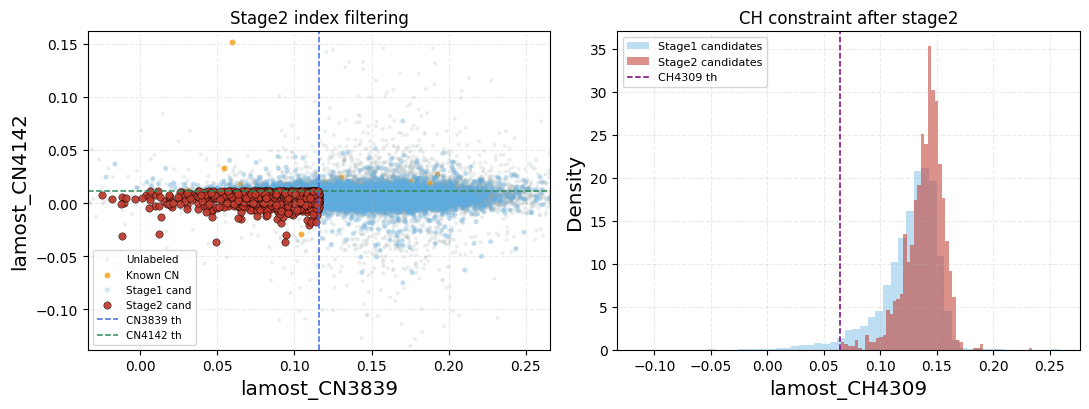

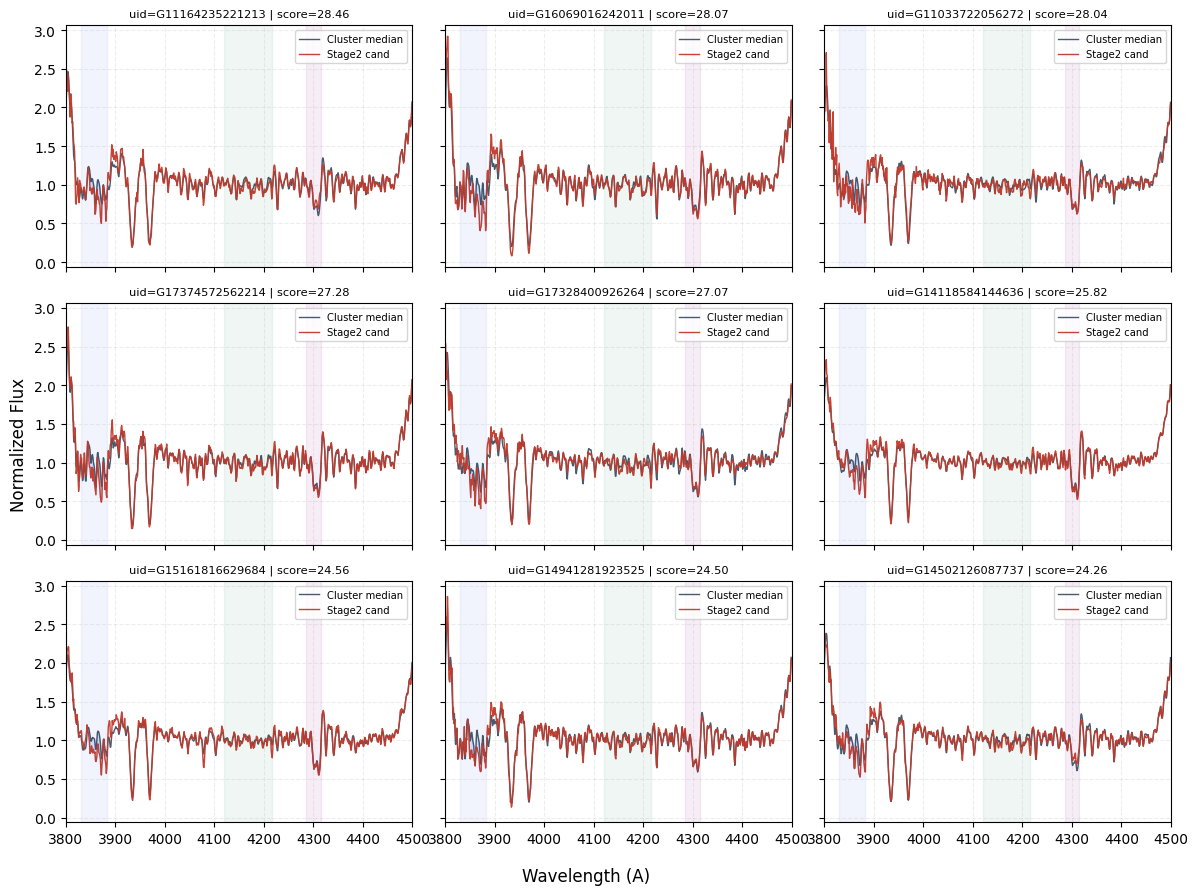

In [24]:
# 二次筛选可视化（指数法）
if 'cn_area_candidates_stage2' not in globals():
    raise RuntimeError('缺少二次筛选结果，请先运行上一单元。')

vis2 = area_screen_df.copy()
m_unl = vis2['label'] == -1
m_kn = vis2['label'] == 1
m_s1 = vis2['cn_area_candidate'] == 1
m_s2 = vis2['cn_area_stage2_candidate'] == 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# 图1：指数平面
axes[0].scatter(
    vis2.loc[m_unl, 'lamost_CN3839'], vis2.loc[m_unl, 'lamost_CN4142'],
    s=8, c='#95a5a6', alpha=0.18, edgecolors='none', label='Unlabeled'
)
axes[0].scatter(
    vis2.loc[m_kn, 'lamost_CN3839'], vis2.loc[m_kn, 'lamost_CN4142'],
    s=20, c='#f39c12', alpha=0.80, edgecolors='white', linewidth=0.3, label='Known CN'
 )
axes[0].scatter(
    vis2.loc[m_s1, 'lamost_CN3839'], vis2.loc[m_s1, 'lamost_CN4142'],
    s=14, c='#5dade2', alpha=0.30, edgecolors='none', label='Stage1 cand'
 )
axes[0].scatter(
    vis2.loc[m_s2, 'lamost_CN3839'], vis2.loc[m_s2, 'lamost_CN4142'],
    s=28, c='#c0392b', alpha=0.92, edgecolors='black', linewidth=0.35, label='Stage2 cand'
 )
axes[0].axvline(th_idx_cn3839, color='royalblue', linestyle='--', linewidth=1.1, label='CN3839 th')
axes[0].axhline(th_idx_cn4142, color='seagreen', linestyle='--', linewidth=1.1, label='CN4142 th')
axes[0].set_xlim(th_idx_cn3839 - 0.15, th_idx_cn3839 + 0.15)
axes[0].set_ylim(th_idx_cn4142 - 0.15, th_idx_cn4142 + 0.15)
axes[0].set_xlabel('lamost_CN3839')
axes[0].set_ylabel('lamost_CN4142')
axes[0].set_title('Stage2 index filtering')
axes[0].grid(alpha=0.25, linestyle='--')
axes[0].legend(loc='best', fontsize=7.5)

# 图2：CH 指数分布
bins = 55
ch1 = vis2.loc[m_s1, 'lamost_CH4309'].values
ch2 = vis2.loc[m_s2, 'lamost_CH4309'].values
axes[1].hist(ch1[np.isfinite(ch1)], bins=bins, density=True, alpha=0.40, color='#5dade2', label='Stage1 candidates')
if np.any(np.isfinite(ch2)):
    axes[1].hist(ch2[np.isfinite(ch2)], bins=bins, density=True, alpha=0.55, color='#c0392b', label='Stage2 candidates')
axes[1].axvline(th_idx_ch4309, color='purple', linestyle='--', linewidth=1.1, label='CH4309 th')
axes[1].set_xlabel('lamost_CH4309')
axes[1].set_ylabel('Density')
axes[1].set_title('CH constraint after stage2')
axes[1].grid(alpha=0.25, linestyle='--')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()
# Top候选光谱：标题统一 uid + score
if len(cn_area_candidates_stage2) == 0:
    print('二次筛选后无候选，跳过光谱可视化。')
else:
    n_show = min(9, len(cn_area_candidates_stage2))
    show2 = cn_area_candidates_stage2.head(n_show).copy()
    idxs = show2['spec_idx'].astype(int).tolist()

    ncols = 3
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)

    for k, i in enumerate(idxs):
        ax = axes[k]
        flux = np.asarray(X_clean[i], dtype=float)
        cid = int(stars_clean.iloc[i]['masked_cluster_id'])
        ref = np.asarray(cluster_median_flux[cid], dtype=float)

        ax.plot(common_wave, ref, color='#34495e', lw=1.0, alpha=0.9, label='Cluster median')
        ax.plot(common_wave, flux, color='#c0392b', lw=1.0, alpha=0.95, label='Stage2 cand')

        for (l1, l2), col in [((3830, 3883), 'royalblue'), ((4120, 4216), 'seagreen'), ((4285, 4315), 'purple')]:
            m = (common_wave >= l1) & (common_wave <= l2)
            x = common_wave[m]
            y1 = ref[m]
            y2 = flux[m]
            ax.fill_between(x, y1, y2, where=(y1 >= y2), color=col, alpha=0.18)
            ax.axvspan(l1, l2, color=col, alpha=0.07)

        row = show2.iloc[k]
        uid_val = str(row['uid']) if 'uid' in row and pd.notna(row['uid']) else f'spec_idx={i}'
        score_val = float(row['cn_area_score']) if 'cn_area_score' in row and np.isfinite(row['cn_area_score']) else np.nan
        ax.set_title(f'uid={uid_val} | score={score_val:.2f}', fontsize=8.2)
        ax.set_xlim(3800, 4500)
        ax.grid(alpha=0.22, linestyle='--')
        ax.legend(loc='upper right', fontsize=7.2)

    for j in range(len(idxs), len(axes)):
        axes[j].axis('off')

    fig.supxlabel('Wavelength (A)')
    fig.supylabel('Normalized Flux')
    plt.tight_layout()
    plt.show()

# 三参数筛选

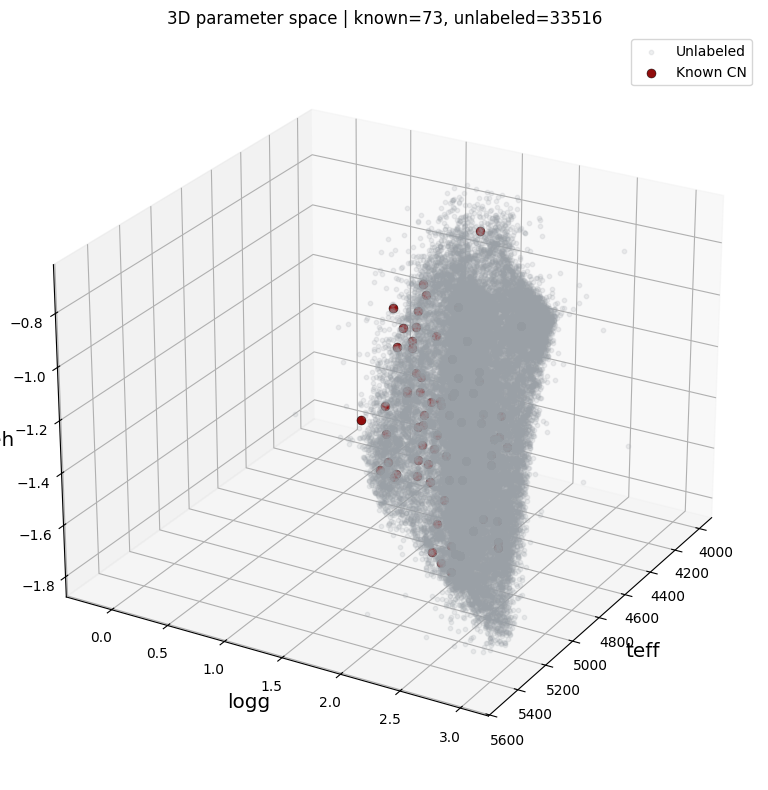

In [25]:
# 第三步诊断：teff-logg-feh 三参数 3D 散点 + 已标注星聚集性检验
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

need_cols = ['teff', 'logg', 'feh', 'label']
if 'area_screen_df' in globals() and set(need_cols).issubset(area_screen_df.columns):
    df3 = area_screen_df[need_cols].copy()
else:
    df3 = stars_clean[need_cols].copy()

for c in ['teff', 'logg', 'feh', 'label']:
    df3[c] = pd.to_numeric(df3[c], errors='coerce')
df3 = df3.dropna(subset=['teff', 'logg', 'feh', 'label']).reset_index(drop=True)

mask_known = df3['label'] == 1
mask_unl = df3['label'] == -1
n_all = len(df3)
n_known = int(mask_known.sum())
n_unl = int(mask_unl.sum())

if n_known < 6:
    raise RuntimeError(f'已标注样本过少（n={n_known}），无法稳定做聚集性判断。')

# 3D 散点（风格参考 XGB：视角+双层散点）
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df3.loc[mask_unl, 'teff'], df3.loc[mask_unl, 'logg'], df3.loc[mask_unl, 'feh'],
    s=10, c='#9aa0a6', alpha=0.16, depthshade=False, label='Unlabeled'
 )
ax.scatter(
    df3.loc[mask_known, 'teff'], df3.loc[mask_known, 'logg'], df3.loc[mask_known, 'feh'],
    s=42, c='#8b0000', alpha=0.95, edgecolors='black', linewidth=0.35, depthshade=False, label='Known CN'
 )

ax.set_xlabel('teff')
ax.set_ylabel('logg')
ax.set_zlabel('feh')
ax.set_title(f'3D parameter space | known={n_known}, unlabeled={n_unl}')
ax.view_init(elev=25, azim=30)
ax.grid(alpha=0.25, linestyle='--')
ax.legend(loc='best')
plt.tight_layout()
plt.show()



三参数聚类完成: n=33589, k=45


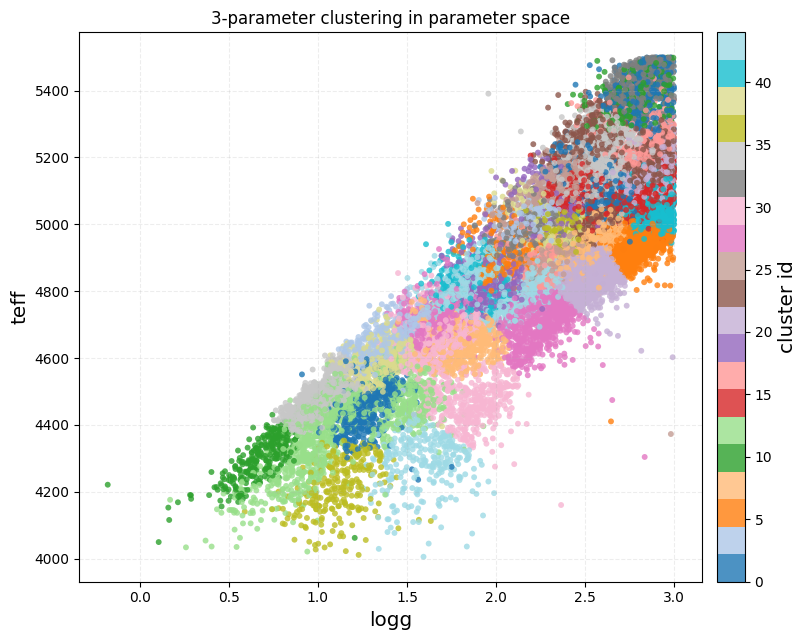

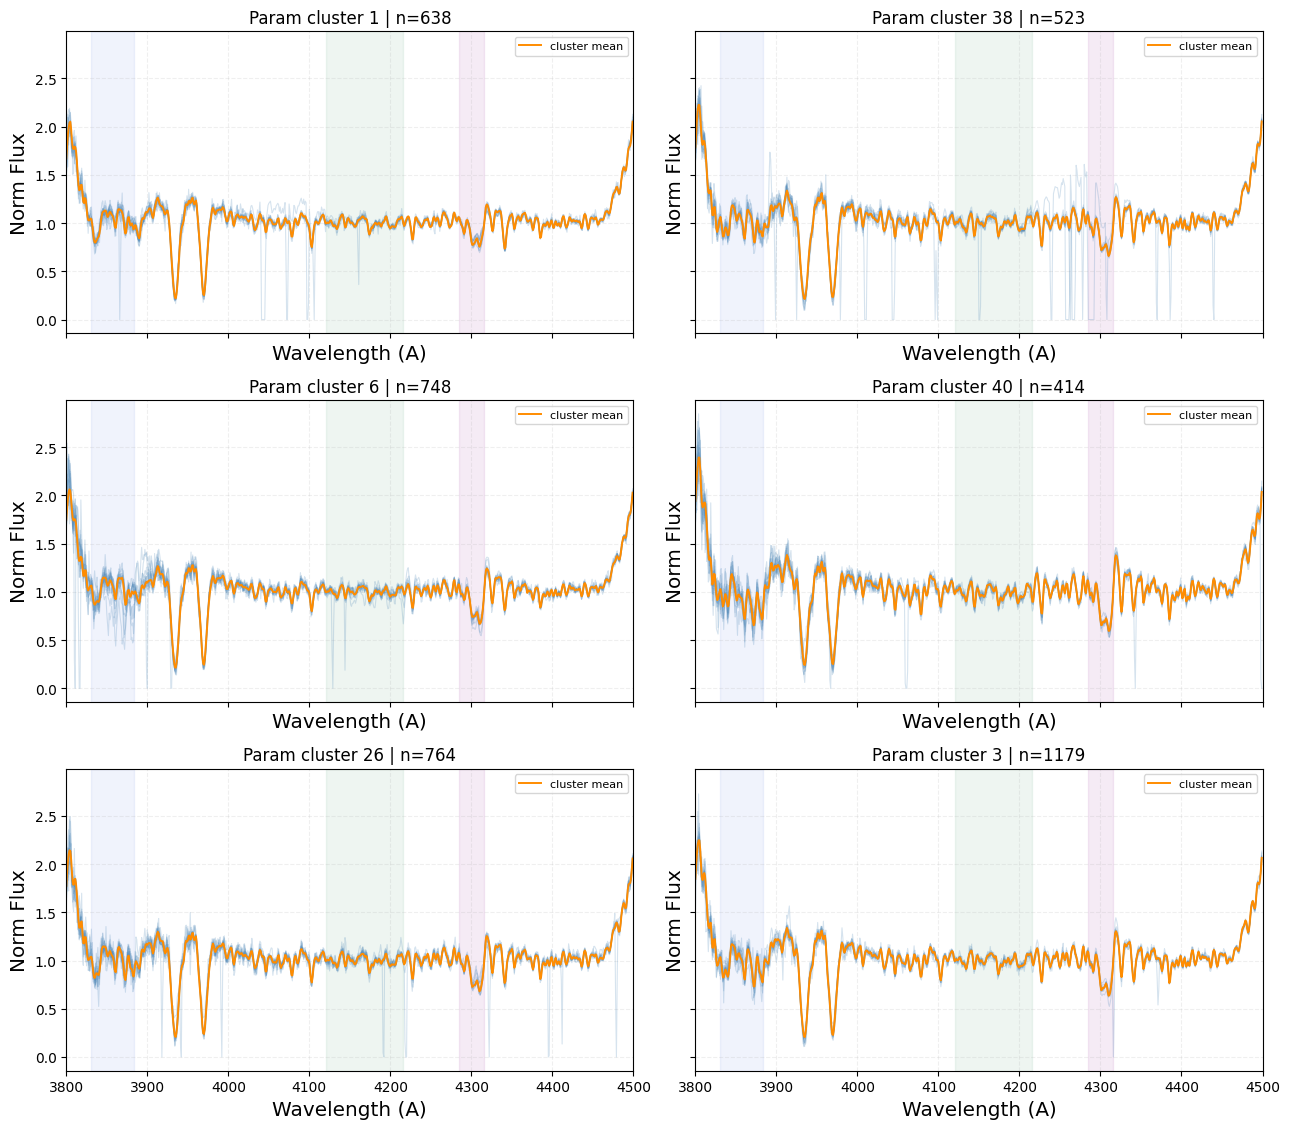

In [38]:
# 纯三参数聚类：只用 teff / logg / feh 做聚类，再随机展示簇内光谱
three_cols = ['teff', 'logg', 'feh']
missing = [c for c in three_cols if c not in stars_clean.columns]
if missing:
    raise RuntimeError(f'缺少三参数列: {missing}')
if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，请先运行光谱预处理单元。')
if len(X_clean) != len(stars_clean):
    raise RuntimeError('X_clean 与 stars_clean 行数不一致，无法做三参数聚类。')

param_df = stars_clean[three_cols].apply(pd.to_numeric, errors='coerce')
valid_mask = param_df.notna().all(axis=1)
param_df = param_df.loc[valid_mask].reset_index(drop=True)

# 对齐后的光谱索引
valid_idx = np.flatnonzero(valid_mask.to_numpy())
X_param = param_df.values
scaler_3p = StandardScaler()
X_param_z = scaler_3p.fit_transform(X_param)

n_samples = len(param_df)
if n_samples < 10:
    raise RuntimeError(f'可用于三参数聚类的样本过少: n={n_samples}')

# 聚类数可按需调整：这里给一个稳妥的默认值
n_clusters_3p = int(np.clip(round(np.sqrt(n_samples) / 2), 4, 45))
kmeans_3p = KMeans(n_clusters=n_clusters_3p, random_state=42, n_init=20)
cluster_3p = kmeans_3p.fit_predict(X_param_z)

param_cluster_df = stars_clean.loc[valid_idx].copy().reset_index(drop=True)
param_cluster_df['param_cluster_id'] = cluster_3p

cluster_counts = param_cluster_df['param_cluster_id'].value_counts().sort_values(ascending=False)
print(f'三参数聚类完成: n={n_samples}, k={n_clusters_3p}')

# 先画参数空间分布，帮助确认簇是否分开
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5))
sc = ax.scatter(
    
    param_cluster_df['logg'],
    param_cluster_df['teff'],
    c=param_cluster_df['param_cluster_id'],
    cmap='tab20',
    s=18,
    alpha=0.80,
    edgecolors='none',
)
ax.set_ylabel('teff')
ax.set_xlabel('logg')
ax.set_title('3-parameter clustering in parameter space')
ax.grid(alpha=0.22, linestyle='--')
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('cluster id')
plt.tight_layout()
plt.show()

# 随机选择若干簇，叠加展示簇内光谱
rng = np.random.default_rng(42)
min_points_per_cluster = 8
eligible_clusters = cluster_counts[cluster_counts >= min_points_per_cluster].index.to_numpy()
if eligible_clusters.size == 0:
    raise RuntimeError('没有满足最小样本数的簇，请调小 min_points_per_cluster。')

n_show_clusters = min(6, eligible_clusters.size)
picked_clusters = rng.choice(eligible_clusters, size=n_show_clusters, replace=False)
max_spectra_each_cluster = 12

ncols = 2
nrows = int(np.ceil(n_show_clusters / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

for i, cid in enumerate(picked_clusters):
    ax = axes[i]
    idxs = np.where(param_cluster_df['param_cluster_id'].values == cid)[0]
    if len(idxs) > max_spectra_each_cluster:
        idxs_plot = rng.choice(idxs, size=max_spectra_each_cluster, replace=False)
    else:
        idxs_plot = idxs

    # 簇内随机光谱
    for idx in idxs_plot:
        spec_idx = int(valid_idx[idx])
        ax.plot(common_wave, X_clean[spec_idx], color='steelblue', alpha=0.22, linewidth=0.8)

    # 簇均值光谱
    cluster_mean = np.nanmean(X_clean[valid_idx[idxs]], axis=0)
    ax.plot(common_wave, cluster_mean, color='darkorange', linewidth=1.4, label='cluster mean')

    # 标出 CN/CH 带
    for l1, l2, col in [(3830, 3883, 'royalblue'), (4120, 4216, 'seagreen'), (4285, 4315, 'purple')]:
        ax.axvspan(l1, l2, color=col, alpha=0.08)

    ax.set_title(f'Param cluster {int(cid)} | n={len(idxs)}')
    ax.set_xlim(3800, 4500)
    ax.set_xlabel('Wavelength (A)')
    ax.set_ylabel('Norm Flux')
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(loc='best', fontsize=8)

for j in range(n_show_clusters, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# 三参数聚类（teff/logg/feh）下的面积积分筛选：仿照单元格11
from scipy import signal

if 'param_cluster_df' not in globals() or 'param_cluster_id' not in param_cluster_df.columns:
    raise RuntimeError('缺少 param_cluster_df/param_cluster_id，请先运行三参数聚类单元。')
if 'valid_idx' not in globals() or len(valid_idx) != len(param_cluster_df):
    raise RuntimeError('缺少 valid_idx 或与 param_cluster_df 长度不一致。')
if 'X_clean' not in globals() or len(X_clean) != len(stars_clean):
    raise RuntimeError('缺少 X_clean 或行数不一致，无法进行面积积分筛选。')

band_cn_3p = {
    'CN3839': (3830, 3883),
    'CN4142': (4120, 4216),
    'CH4300': (4285, 4315),
}

def _safe_smooth_3p(y, win=9, poly=2):
    y = np.asarray(y, dtype=float)
    w = int(win)
    if w % 2 == 0:
        w += 1
    if y.size < max(w, poly + 3):
        return y
    return signal.savgol_filter(y, window_length=w, polyorder=poly, mode='interp')

def _trapz_signed_3p(y, x):
    return float(np.trapz(y, x))

def robust_zscore_3p(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    mad = np.nanmedian(np.abs(arr - med)) + 1e-8
    return (arr - med) / mad

def robust_upper_3p(x, q=0.995, k=5.0):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-8
    return float(min(med + k * mad, np.nanquantile(x, q)))

# 1) 构建三参数簇参考中位谱（在 valid_idx 子集上）
cluster_median_flux_3p = {}
cluster_ids_3p = param_cluster_df['param_cluster_id'].values
for cid in np.unique(cluster_ids_3p):
    idxs_local = np.where(cluster_ids_3p == cid)[0]
    idxs_global = valid_idx[idxs_local]
    cluster_median_flux_3p[int(cid)] = np.nanmedian(X_clean[idxs_global], axis=0)

# 2) 计算面积特征
rows_3p = []
for i in range(len(param_cluster_df)):
    cid = int(cluster_ids_3p[i])
    spec_idx = int(valid_idx[i])
    flux = np.asarray(X_clean[spec_idx], dtype=float)
    ref = np.asarray(cluster_median_flux_3p[cid], dtype=float)
    diff_raw = ref - flux
    diff_smooth = _safe_smooth_3p(diff_raw, win=9, poly=2)

    rec = {'spec_idx': spec_idx}
    for name, (l1, l2) in band_cn_3p.items():
        m = (common_wave >= l1) & (common_wave <= l2)
        x = common_wave[m]
        d_raw = diff_raw[m]
        d_sm = diff_smooth[m]
        width = max(float(l2 - l1), 1.0)
        rec[f'{name}_signed_area'] = _trapz_signed_3p(d_sm, x) / width
        rec[f'{name}_abs_frac'] = float(np.mean(d_sm > 0)) if d_sm.size > 0 else np.nan
        rec[f'{name}_peak_depth'] = float(np.nanmax(d_raw)) if d_raw.size > 0 else np.nan
    rows_3p.append(rec)

area3_df = pd.DataFrame(rows_3p)
area3_screen_df = pd.concat([param_cluster_df.reset_index(drop=True), area3_df], axis=1)

for c in ['CN3839_signed_area', 'CN4142_signed_area']:
    area3_screen_df[c] = area3_screen_df[c] - float(np.nanmedian(area3_screen_df[c].values))

area3_screen_df['z_CN3839_area'] = robust_zscore_3p(area3_screen_df['CN3839_signed_area'].values)
area3_screen_df['z_CN4142_area'] = robust_zscore_3p(area3_screen_df['CN4142_signed_area'].values)
area3_screen_df['cn_shape_score'] = np.minimum(area3_screen_df['z_CN3839_area'], area3_screen_df['z_CN4142_area'])
area3_screen_df['cn_area_score'] = (
    0.85 * area3_screen_df['z_CN3839_area']
    + 0.85 * area3_screen_df['z_CN4142_area']
    + 0.75 * area3_screen_df['cn_shape_score']
)

known_mask_3p = area3_screen_df['label'] == 1
unl_mask_3p = area3_screen_df['label'] == -1
n_known_3p = int(known_mask_3p.sum())
n_unl_3p = int(unl_mask_3p.sum())

ch_center_3p = float(np.nanmedian(area3_screen_df.loc[known_mask_3p, 'CH4300_signed_area'].values)) if n_known_3p > 0 else float(np.nanmedian(area3_screen_df['CH4300_signed_area'].values))
area3_screen_df['CH4300_dev_abs'] = np.abs(area3_screen_df['CH4300_signed_area'].values - ch_center_3p)

# 3) 基础约束
kn_cn3839_3p = area3_screen_df.loc[known_mask_3p, 'CN3839_signed_area'].values if n_known_3p > 0 else area3_screen_df['CN3839_signed_area'].values
kn_cn4142_3p = area3_screen_df.loc[known_mask_3p, 'CN4142_signed_area'].values if n_known_3p > 0 else area3_screen_df['CN4142_signed_area'].values
th_cn3839_3p = float(np.nanquantile(kn_cn3839_3p, 0.03))
th_cn4142_3p = float(np.nanquantile(kn_cn4142_3p, 0.03))
ub_cn3839_3p = robust_upper_3p(kn_cn3839_3p, q=0.999, k=5.5)
ub_cn4142_3p = robust_upper_3p(kn_cn4142_3p, q=0.999, k=5.5)
th_frac3839_3p = max(float(np.nanquantile(area3_screen_df.loc[known_mask_3p, 'CN3839_abs_frac'].values if n_known_3p > 0 else area3_screen_df['CN3839_abs_frac'].values, 0.02)), 0.10)
th_frac4142_3p = max(float(np.nanquantile(area3_screen_df.loc[known_mask_3p, 'CN4142_abs_frac'].values if n_known_3p > 0 else area3_screen_df['CN4142_abs_frac'].values, 0.02)), 0.10)
th_peak_4142_3p = float(np.nanquantile(area3_screen_df.loc[known_mask_3p, 'CN4142_peak_depth'].values if n_known_3p > 0 else area3_screen_df['CN4142_peak_depth'].values, 0.9995))

known_cn_band_3p = area3_screen_df.loc[known_mask_3p, ['CN3839_signed_area', 'CN4142_signed_area']].values if n_known_3p > 0 else area3_screen_df[['CN3839_signed_area', 'CN4142_signed_area']].values
med_k_cn_3p = np.nanmedian(known_cn_band_3p, axis=0)
mad_k_cn_3p = np.nanmedian(np.abs(known_cn_band_3p - med_k_cn_3p), axis=0) + 1e-8
all_cn_band_3p = area3_screen_df[['CN3839_signed_area', 'CN4142_signed_area']].values
known_like_dist_3p = np.sqrt(np.nansum(((all_cn_band_3p - med_k_cn_3p) / mad_k_cn_3p) ** 2, axis=1))
area3_screen_df['known_like_dist'] = known_like_dist_3p
th_known_like_3p = float(np.nanquantile(known_like_dist_3p[known_mask_3p.values], 0.999) + 2.0) if n_known_3p > 0 else float(np.nanquantile(known_like_dist_3p, 0.999))

base_mask_3p = (
    (area3_screen_df['CN3839_signed_area'] >= th_cn3839_3p)
    & (area3_screen_df['CN4142_signed_area'] >= th_cn4142_3p)
    & (area3_screen_df['CN3839_signed_area'] <= ub_cn3839_3p)
    & (area3_screen_df['CN4142_signed_area'] <= ub_cn4142_3p)
    & (area3_screen_df['CN3839_abs_frac'] >= th_frac3839_3p)
    & (area3_screen_df['CN4142_abs_frac'] >= th_frac4142_3p)
    & (area3_screen_df['CN4142_peak_depth'] <= th_peak_4142_3p)
    & (area3_screen_df['known_like_dist'] <= th_known_like_3p)
)

# 4) 固定参数：与单元格11一致
th_shape_3p = -0.55
th_score_3p = 1.10
ch_dev_limit_3p = 0.045

area_rule_mask_3p = base_mask_3p & (
    (area3_screen_df['cn_shape_score'] >= th_shape_3p)
    & (area3_screen_df['cn_area_score'] >= th_score_3p)
    & (area3_screen_df['CH4300_dev_abs'] <= ch_dev_limit_3p)
)

area_candidate_mask_3p = area_rule_mask_3p & (area3_screen_df['label'] == -1)
area_known_hit_mask_3p = area_rule_mask_3p & (area3_screen_df['label'] == 1)

area3_screen_df['cn_area_rule_hit_3p'] = area_rule_mask_3p.astype(int)
area3_screen_df['cn_area_known_hit_3p'] = area_known_hit_mask_3p.astype(int)
area3_screen_df['cn_area_candidate_3p'] = area_candidate_mask_3p.astype(int)

cn_area_candidates_3p = area3_screen_df.loc[area_candidate_mask_3p].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)
n_total_3p = len(area3_screen_df)
n_known_hit_3p = int(area_known_hit_mask_3p.sum())
area_known_recall_3p = float(n_known_hit_3p / max(n_known_3p, 1))

print(f'有效样本数(valid subset): {n_total_3p}')
print(f'候选数: {len(cn_area_candidates_3p)}')
print(f'召回数: {n_known_hit_3p}')
print(f'召回率: {area_known_recall_3p:.3f}')
print(f'已知CN数量(valid subset): {n_known_3p}')
print(f'未标注数量(valid subset): {n_unl_3p}')


top_cols_3p = [
    c for c in [
        'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'filepath',
        'CN3839_signed_area', 'CN4142_signed_area', 'CH4300_signed_area',
        'cn_shape_score', 'cn_area_score', 'CH4300_dev_abs'
    ] if c in cn_area_candidates_3p.columns
]
print('\nTop10候选参数(三参数KNN):')
display(cn_area_candidates_3p[top_cols_3p].head(10))

=== 三参数聚类面积筛选结果 ===
有效样本数(valid subset): 33589
候选数: 7169
召回数: 64
召回率: 0.877
已知CN数量(valid subset): 73
未标注数量(valid subset): 33516

Top10候选参数(三参数KNN):


,uid,ra,dec,teff,logg,feh,rv,snru,filepath,CN3839_signed_area,CN4142_signed_area,CH4300_signed_area,cn_shape_score,cn_area_score,CH4300_dev_abs
0,G16665632766330,59.715710,18.773125,4851.71,2.068,-1.419,64.05,9.39,dr13_new\spec-58879-KII035606N204618V01_sp01-1...,0.173499,0.025065,0.016488,16.577945,42.651944,0.022738
1,G11033722056272,199.042368,-2.057600,4949.71,2.292,-1.353,35.89,5.60,dr13_new\spec-57887-HD131404S024825V02_sp09-17...,0.175318,0.024314,0.014629,16.080856,42.025688,0.020879
2,G13257970270069,356.643696,9.188883,4845.32,1.740,-1.321,-154.34,6.45,dr13_new\spec-57291-EG234156N071501V01_sp12-04...,0.150075,0.028027,0.032812,16.411634,42.014605,0.039062
3,G14502126087737,248.593692,23.235639,4956.85,2.472,-0.984,-54.83,14.73,dr13_new\spec-56782-HD162506N240323B01_sp06-11...,0.147756,0.025978,-0.025207,16.158061,40.457201,0.018958
4,G17360309414977,33.512733,40.437796,4730.11,1.410,-1.118,-54.79,5.06,dr13_new\spec-59942-HD020840N420946B03_sp07-15...,0.132818,0.028922,0.026327,14.524450,39.498559,0.032577
5,G16556113395539,85.353079,8.876676,4783.62,2.119,-0.715,15.63,10.17,dr13_new\spec-57697-GAC084N09B1_sp08-181.fits.gz,0.128222,0.028452,-0.017145,14.021861,38.430079,0.010895
6,P17537592696628,53.779184,26.240602,4638.97,1.509,-1.026,-16.31,6.47,dr13_new\spec-60233-LN033906N244210BM01_sp16-2...,0.111258,0.032107,0.027873,12.166779,37.517008,0.034123
7,G14085846413883,293.784208,45.080778,4503.70,1.528,-0.902,-19.66,10.79,dr13_new\spec-56914-KP193637N444141V02_sp04-02...,0.109388,0.032448,0.022974,11.962318,37.381568,0.029224
8,G15626569425898,157.985949,7.647300,5091.62,2.187,-1.073,-30.24,5.89,dr13_new\spec-60759-LN103605N070210VB01_sp03-2...,0.147465,0.021512,-0.021452,14.227485,36.471315,0.015202
9,G15389099527966,228.931534,33.060727,4812.26,2.608,-0.716,-22.88,6.05,dr13_new\spec-58165-HD150818N334223B01_sp06-22...,0.122896,0.025924,0.019037,13.439452,36.076907,0.025287


In [42]:
# 三参数面积筛选后的二次筛选：参考前面分子带指数法
if 'area3_screen_df' not in globals() or 'cn_area_candidates_3p' not in globals():
    raise RuntimeError('缺少三参数面积筛选结果，请先运行上一单元。')
if 'X_clean' not in globals() or 'common_wave' not in globals():
    raise RuntimeError('缺少 X_clean/common_wave，无法计算指数法。')

# 若前文未定义，则在此补充
if 'normalize_continuum' not in globals():
    def normalize_continuum(flux, wave, deg=3):
        flux = np.asarray(flux, dtype=float)
        wave = np.asarray(wave, dtype=float)
        ok = np.isfinite(flux) & np.isfinite(wave)
        if ok.sum() < 10:
            return np.full_like(flux, np.nan, dtype=float)
        p = np.polyfit(wave[ok], flux[ok], deg)
        cont = np.polyval(p, wave)
        cont = np.where(np.isfinite(cont) & (np.abs(cont) > 1e-8), cont, np.nan)
        return flux / cont

if 'compute_index_lamost' not in globals():
    def compute_index_lamost(flux, wave, band, blue, red):
        flux = np.asarray(flux, dtype=float)
        wave = np.asarray(wave, dtype=float)

        m_band = (wave >= band[0]) & (wave <= band[1])
        m_blue = (wave >= blue[0]) & (wave <= blue[1])
        m_red = (wave >= red[0]) & (wave <= red[1])

        if (m_band.sum() < 3) or (m_blue.sum() < 3) or (m_red.sum() < 3):
            return np.nan

        f_band = np.nanmean(flux[m_band])
        f_blue = np.nanmean(flux[m_blue])
        f_red = np.nanmean(flux[m_red])
        f_cont = 0.5 * (f_blue + f_red)

        if (not np.isfinite(f_band)) or (not np.isfinite(f_cont)) or (f_band <= 0) or (f_cont <= 0):
            return np.nan
        return -2.5 * np.log10(f_band / f_cont)

index_bands_3p = {
    'lamost_CN3839': {'band': (3839 - 15, 3839 + 15), 'blue': (3810, 3830), 'red': (3860, 3870)},
    'lamost_CN4142': {'band': (4142 - 40, 4142 + 40), 'blue': (4120, 4135), 'red': (4160, 4175)},
    'lamost_CH4309': {'band': (4309 - 20, 4309 + 20), 'blue': (4270, 4290), 'red': (4330, 4350)},
}

# 计算三参数子集每条光谱的指数
idx_cn3839_3p, idx_cn4142_3p, idx_ch4309_3p = [], [], []
for i in range(len(area3_screen_df)):
    spec_i = int(area3_screen_df.iloc[i]['spec_idx'])
    f_norm = normalize_continuum(X_clean[spec_i], common_wave, deg=3)
    idx_cn3839_3p.append(compute_index_lamost(f_norm, common_wave, **index_bands_3p['lamost_CN3839']))
    idx_cn4142_3p.append(compute_index_lamost(f_norm, common_wave, **index_bands_3p['lamost_CN4142']))
    idx_ch4309_3p.append(compute_index_lamost(f_norm, common_wave, **index_bands_3p['lamost_CH4309']))

area3_screen_df['lamost_CN3839'] = np.asarray(idx_cn3839_3p, dtype=float)
area3_screen_df['lamost_CN4142'] = np.asarray(idx_cn4142_3p, dtype=float)
area3_screen_df['lamost_CH4309'] = np.asarray(idx_ch4309_3p, dtype=float)

# 一阶段全体命中（含已知+未标注）
stage1_all_mask_3p = area3_screen_df['cn_area_rule_hit_3p'] == 1
known_stage1_mask_3p = stage1_all_mask_3p & (area3_screen_df['label'] == 1)
if int(known_stage1_mask_3p.sum()) < 8:
    raise RuntimeError('三参数一阶段命中的已知CN过少，无法稳定做二次召回评估。')

# 阈值口径与前面一致，方便对比
q_cn3839_3p = 0.80
q_cn4142_3p = 0.80
q_ch4309_3p = 0.05
th_idx_cn3839_3p = float(np.nanquantile(area3_screen_df.loc[known_stage1_mask_3p, 'lamost_CN3839'], q_cn3839_3p))
th_idx_cn4142_3p = float(np.nanquantile(area3_screen_df.loc[known_stage1_mask_3p, 'lamost_CN4142'], q_cn4142_3p))
th_idx_ch4309_3p = float(np.nanquantile(area3_screen_df.loc[known_stage1_mask_3p, 'lamost_CH4309'], q_ch4309_3p))

finite_idx_mask_3p = np.isfinite(area3_screen_df[['lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309']]).all(axis=1)
stage2_all_mask_3p = stage1_all_mask_3p & finite_idx_mask_3p & (
    (area3_screen_df['lamost_CN3839'] <= th_idx_cn3839_3p)
    & (area3_screen_df['lamost_CN4142'] <= th_idx_cn4142_3p)
    & (area3_screen_df['lamost_CH4309'] >= th_idx_ch4309_3p)
)
stage2_unl_mask_3p = stage2_all_mask_3p & (area3_screen_df['label'] == -1)
known_stage2_hit_mask_3p = stage2_all_mask_3p & (area3_screen_df['label'] == 1)

area3_screen_df['cn_area_stage2_hit_3p'] = stage2_all_mask_3p.astype(int)
area3_screen_df['cn_area_stage2_candidate_3p'] = stage2_unl_mask_3p.astype(int)

cn_area_candidates_stage2_3p = area3_screen_df.loc[stage2_unl_mask_3p].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)
stage2_recall_count_3p = int(known_stage2_hit_mask_3p.sum())
stage2_recall_rate_3p = float(stage2_recall_count_3p / max(int((area3_screen_df['label'] == 1).sum()), 1))

print(f'一阶段候选数(面积): {len(cn_area_candidates_3p)}')
print(f'二阶段候选数(指数后): {len(cn_area_candidates_stage2_3p)}')
print(f'二阶段召回数: {stage2_recall_count_3p}')
print(f'二阶段召回率: {stage2_recall_rate_3p:.3f}')



top2_cols_3p = [
    c for c in [
        'uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'rv', 'snru', 'filepath',
        'lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309', 'cn_area_score'
    ] if c in cn_area_candidates_stage2_3p.columns
]
print('\n二次筛选 Top10候选参数(三参数KNN):')
display(cn_area_candidates_stage2_3p[top2_cols_3p].head(10))

一阶段候选数(面积): 7169
二阶段候选数(指数后): 1335
二阶段召回数: 39
二阶段召回率: 0.534

二次筛选 Top10候选参数(三参数KNN):


,uid,ra,dec,teff,logg,feh,rv,snru,filepath,lamost_CN3839,lamost_CN4142,lamost_CH4309,cn_area_score
0,G11033722056272,199.042368,-2.057600,4949.71,2.292,-1.353,35.89,5.60,dr13_new\spec-57887-HD131404S024825V02_sp09-17...,0.077752,0.010403,0.124417,42.025688
1,G13257970270069,356.643696,9.188883,4845.32,1.740,-1.321,-154.34,6.45,dr13_new\spec-57291-EG234156N071501V01_sp12-04...,0.009273,-0.003172,0.145051,42.014605
2,G14502126087737,248.593692,23.235639,4956.85,2.472,-0.984,-54.83,14.73,dr13_new\spec-56782-HD162506N240323B01_sp06-11...,0.059125,0.010880,0.114000,40.457201
3,G17360309414977,33.512733,40.437796,4730.11,1.410,-1.118,-54.79,5.06,dr13_new\spec-59942-HD020840N420946B03_sp07-15...,0.114903,0.003469,0.151329,39.498559
4,P17537592696628,53.779184,26.240602,4638.97,1.509,-1.026,-16.31,6.47,dr13_new\spec-60233-LN033906N244210BM01_sp16-2...,0.047040,0.010918,0.157851,37.517008
5,G16152214419377,115.009839,19.967869,4867.90,1.929,-1.151,-14.72,17.92,dr13_new\spec-60618-LN073705N200924BM01_sp08-2...,0.104395,0.005893,0.146662,36.033576
6,G17488399636409,57.549739,48.557628,4879.27,1.745,-1.075,17.17,42.99,dr13_new\spec-57319-HD034854N505024V01_sp01-00...,0.088991,0.009947,0.136356,35.795208
7,G16361104128929,165.266077,46.013535,4771.62,1.874,-0.983,5.45,7.61,dr13_new\spec-59192-HD105355N474016V01_sp07-07...,0.079642,0.007414,0.161882,35.408593
8,G15382274155086,227.886440,30.985630,4603.29,1.562,-1.078,11.97,7.25,dr13_new\spec-56698-HD151053N291344V_sp11-234....,0.058780,0.008788,0.148830,34.521582
9,G13902276368080,273.190952,23.063000,4647.07,1.440,-0.777,-100.57,15.92,dr13_new\spec-56760-HD180440N235631V01_sp06-22...,0.069547,-0.000681,0.166095,34.505297


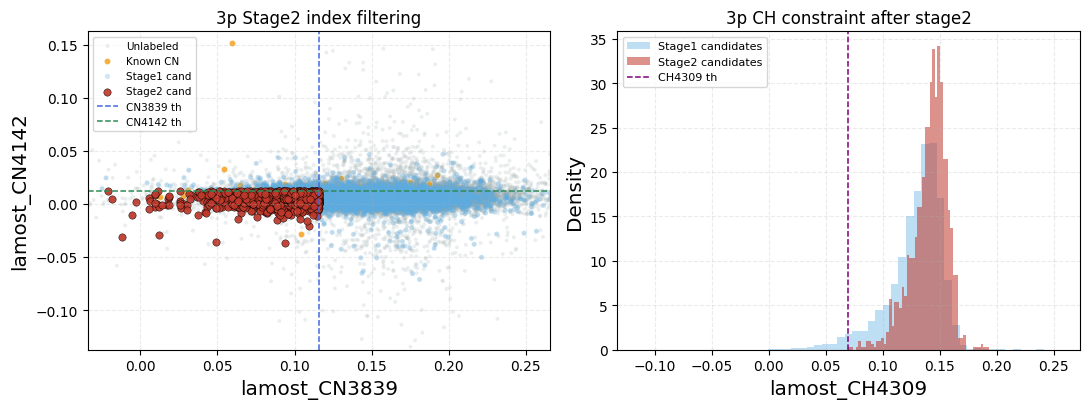

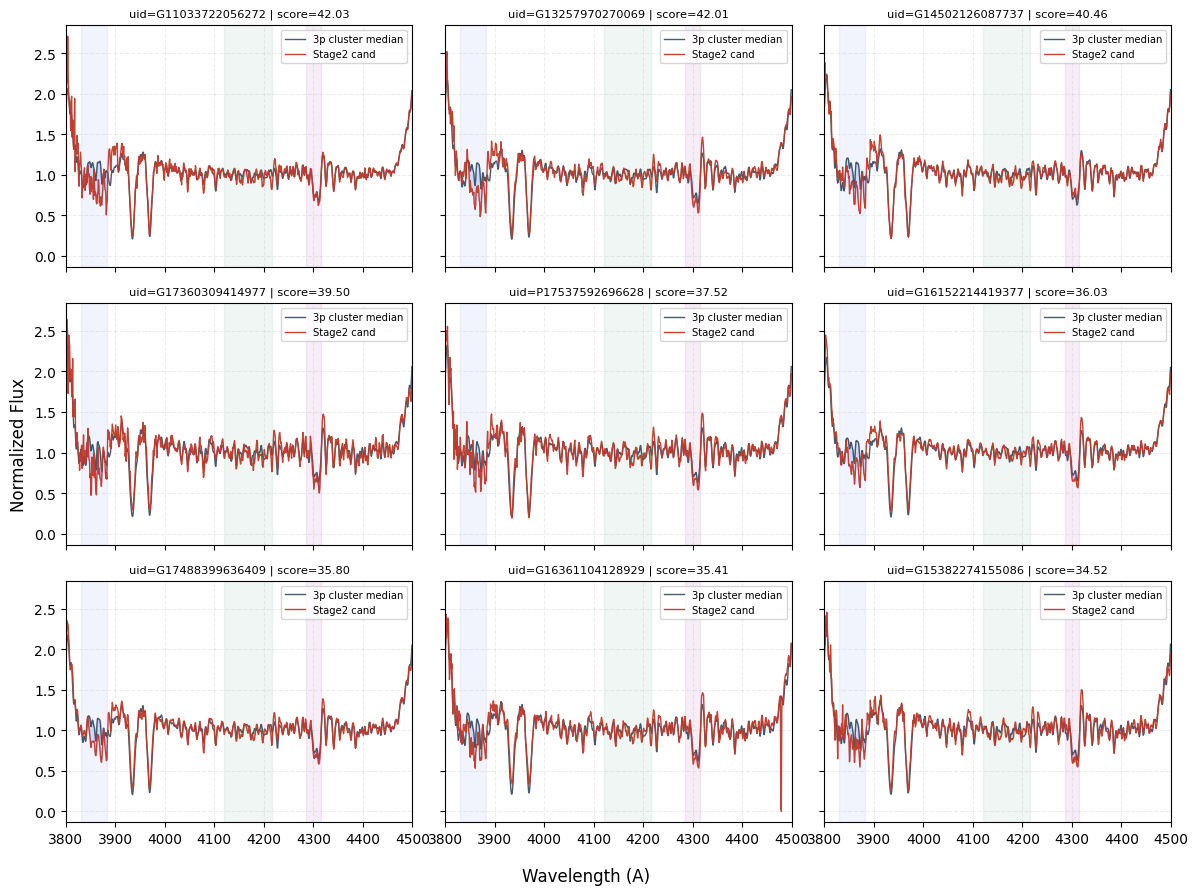

In [41]:
# 三参数流程二次筛选可视化（指数法）
if 'cn_area_candidates_stage2_3p' not in globals():
    raise RuntimeError('缺少三参数二次筛选结果，请先运行上一单元。')

vis2_3p = area3_screen_df.copy()
m_unl_3p = vis2_3p['label'] == -1
m_kn_3p = vis2_3p['label'] == 1
m_s1_3p = vis2_3p['cn_area_candidate_3p'] == 1
m_s2_3p = vis2_3p['cn_area_stage2_candidate_3p'] == 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# 图1：指数平面
axes[0].scatter(
    vis2_3p.loc[m_unl_3p, 'lamost_CN3839'], vis2_3p.loc[m_unl_3p, 'lamost_CN4142'],
    s=8, c='#95a5a6', alpha=0.18, edgecolors='none', label='Unlabeled'
)
axes[0].scatter(
    vis2_3p.loc[m_kn_3p, 'lamost_CN3839'], vis2_3p.loc[m_kn_3p, 'lamost_CN4142'],
    s=20, c='#f39c12', alpha=0.80, edgecolors='white', linewidth=0.3, label='Known CN'
)
axes[0].scatter(
    vis2_3p.loc[m_s1_3p, 'lamost_CN3839'], vis2_3p.loc[m_s1_3p, 'lamost_CN4142'],
    s=14, c='#5dade2', alpha=0.30, edgecolors='none', label='Stage1 cand'
)
axes[0].scatter(
    vis2_3p.loc[m_s2_3p, 'lamost_CN3839'], vis2_3p.loc[m_s2_3p, 'lamost_CN4142'],
    s=28, c='#c0392b', alpha=0.92, edgecolors='black', linewidth=0.35, label='Stage2 cand'
)
axes[0].axvline(th_idx_cn3839_3p, color='royalblue', linestyle='--', linewidth=1.1, label='CN3839 th')
axes[0].axhline(th_idx_cn4142_3p, color='seagreen', linestyle='--', linewidth=1.1, label='CN4142 th')
axes[0].set_xlim(th_idx_cn3839_3p - 0.15, th_idx_cn3839_3p + 0.15)
axes[0].set_ylim(th_idx_cn4142_3p - 0.15, th_idx_cn4142_3p + 0.15)
axes[0].set_xlabel('lamost_CN3839')
axes[0].set_ylabel('lamost_CN4142')
axes[0].set_title('3p Stage2 index filtering')
axes[0].grid(alpha=0.25, linestyle='--')
axes[0].legend(loc='best', fontsize=7.5)

# 图2：CH 指数分布
bins_3p = 55
ch1_3p = vis2_3p.loc[m_s1_3p, 'lamost_CH4309'].values
ch2_3p = vis2_3p.loc[m_s2_3p, 'lamost_CH4309'].values
axes[1].hist(ch1_3p[np.isfinite(ch1_3p)], bins=bins_3p, density=True, alpha=0.40, color='#5dade2', label='Stage1 candidates')
if np.any(np.isfinite(ch2_3p)):
    axes[1].hist(ch2_3p[np.isfinite(ch2_3p)], bins=bins_3p, density=True, alpha=0.55, color='#c0392b', label='Stage2 candidates')
axes[1].axvline(th_idx_ch4309_3p, color='purple', linestyle='--', linewidth=1.1, label='CH4309 th')
axes[1].set_xlabel('lamost_CH4309')
axes[1].set_ylabel('Density')
axes[1].set_title('3p CH constraint after stage2')
axes[1].grid(alpha=0.25, linestyle='--')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

# Top 候选光谱：使用三参数簇中位谱作为参考
if len(cn_area_candidates_stage2_3p) == 0:
    print('三参数二次筛选后无候选，跳过光谱可视化。')
else:
    n_show_3p = min(9, len(cn_area_candidates_stage2_3p))
    show2_3p = cn_area_candidates_stage2_3p.head(n_show_3p).copy()
    idxs_3p = show2_3p['spec_idx'].astype(int).tolist()

    ncols = 3
    nrows = int(np.ceil(len(idxs_3p) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)

    for k, spec_idx in enumerate(idxs_3p):
        ax = axes[k]
        flux = np.asarray(X_clean[spec_idx], dtype=float)

        local_pos = np.where(valid_idx == spec_idx)[0]
        if len(local_pos) == 0:
            ax.plot(common_wave, flux, color='#c0392b', lw=1.0, alpha=0.95, label='Stage2 cand')
            ref = np.full_like(flux, np.nan)
        else:
            pos = int(local_pos[0])
            cid = int(param_cluster_df.iloc[pos]['param_cluster_id'])
            ref = np.asarray(cluster_median_flux_3p[cid], dtype=float)
            ax.plot(common_wave, ref, color='#34495e', lw=1.0, alpha=0.9, label='3p cluster median')
            ax.plot(common_wave, flux, color='#c0392b', lw=1.0, alpha=0.95, label='Stage2 cand')

        for (l1, l2), col in [((3830, 3883), 'royalblue'), ((4120, 4216), 'seagreen'), ((4285, 4315), 'purple')]:
            m = (common_wave >= l1) & (common_wave <= l2)
            x = common_wave[m]
            y1 = ref[m] if np.any(np.isfinite(ref)) else flux[m]
            y2 = flux[m]
            ax.fill_between(x, y1, y2, where=(y1 >= y2), color=col, alpha=0.18)
            ax.axvspan(l1, l2, color=col, alpha=0.07)

        row = show2_3p.iloc[k]
        uid_val = str(row['uid']) if 'uid' in row and pd.notna(row['uid']) else f'spec_idx={spec_idx}'
        score_val = float(row['cn_area_score']) if 'cn_area_score' in row and np.isfinite(row['cn_area_score']) else np.nan
        ax.set_title(f'uid={uid_val} | score={score_val:.2f}', fontsize=8.2)
        ax.set_xlim(3800, 4500)
        ax.grid(alpha=0.22, linestyle='--')
        ax.legend(loc='upper right', fontsize=7.2)

    for j in range(len(idxs_3p), len(axes)):
        axes[j].axis('off')

    fig.supxlabel('Wavelength (A)')
    fig.supylabel('Normalized Flux')
    plt.tight_layout()
    plt.show()